In [1]:
from dataclasses import dataclass, field
from decimal import Decimal
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from pyspark.sql import functions as F

from pyspark.sql.types import (
    StructType,
    StructField,
    StringType,
    DoubleType,
    IntegerType,
    LongType
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.cm as cm

spark.conf.set(
    "spark.sql.parquet.datetimeRebaseModeInWrite",
    "LEGACY"
)

spark.conf.set(
    "spark.sql.parquet.datetimeRebaseModeInRead",
    "LEGACY"
)

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 3, Finished, Available, Finished, False)

### Leitura dos dados

In [2]:
df_nav_item = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_item")
df_nav_item_attribute_value_mapping = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_item_attribute_value_mapping")
df_nav_item_attribute = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_item_attribute")
df_nav_item_attribute_value = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_item_attribute_value")
df_nav_item_unit_of_measure = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_item_unit_of_measure")
df_nav_posted_whse_shipment_header = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_posted_whse_shipment_header") 
df_nav_volume = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_volume")
df_nav_volume_content = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_volume_content")
df_nav_warehouse_shipment_header= spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_warehouse_shipment_header")
df_nav_warehouse_shipment_line = spark.read.table("INDASA_LAKE_PALETE.bronze.nav01_nav_warehouse_shipment_line")

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 4, Finished, Available, Finished, False)

In [3]:
#metodologia (esconder)
from pyspark.sql import functions as F

print("=" * 60)
print("DIAGNÓSTICO DO ESTADO ATUAL")
print("=" * 60)

# ------------------------------------------------------------
# 1) Cobertura de dimensões
# ------------------------------------------------------------
uom_com_dim = (
    df_nav_item_unit_of_measure
    .filter((F.col("length") > 0) & (F.col("width") > 0) & (F.col("height") > 0))
    .select("item_no").distinct()
)

linhas = (
    df_nav_warehouse_shipment_line
    .filter((F.col("qty_outstanding") > 0) & (F.col("fully_packed") == 0))
)

total_linhas = linhas.count()
com_dim = (
    linhas
    .join(
        df_nav_item_unit_of_measure
        .filter((F.col("length") > 0) & (F.col("width") > 0) & (F.col("height") > 0))
        .select(
            F.col("item_no").alias("uom_item"),
            F.col("code").alias("uom_code"),
        ),
        (linhas["item_no"] == F.col("uom_item")) &
        (linhas["unit_of_measure_code"] == F.col("uom_code")),
        "inner",
    )
    .count()
)

artigos = linhas.select("item_no").distinct().count()
artigos_com_dim = linhas.join(uom_com_dim, on="item_no", how="inner").select("item_no").distinct().count()

print("\n-- Cobertura de dimensões --")
print(f"Linhas de expedição em aberto : {total_linhas}")
print(f"  com dimensões               : {com_dim} ({com_dim/total_linhas*100:.1f}%)")
print(f"  sem dimensões               : {total_linhas-com_dim} ({(total_linhas-com_dim)/total_linhas*100:.1f}%)")
print(f"Artigos distintos             : {artigos}")
print(f"  com dimensões               : {artigos_com_dim} ({artigos_com_dim/artigos*100:.1f}%)")

# ------------------------------------------------------------
# 2) Paletes por expedição (histórico)
# ------------------------------------------------------------
mapa = df_nav_posted_whse_shipment_header.select(
    F.col("no").alias("posted_no"),
    F.col("whse_shipment_no").alias("shipment_no"),
)

paletes = (
    df_nav_volume
    .filter(F.col("volume_type") == "PALETE")
    .join(mapa, df_nav_volume["warehouse_doc_no"] == F.col("posted_no"), "inner")
    .groupBy("shipment_no")
    .agg(F.countDistinct("volume_no").alias("paletes"))
    .toPandas()
)

print("\n-- Paletes por expedição (histórico) --")
print(f"Expedições com palete : {len(paletes)}")
print(f"Total de paletes      : {paletes['paletes'].sum()}")
print(f"Média                 : {paletes['paletes'].mean():.1f}")
print(f"Mediana               : {paletes['paletes'].median():.0f}")
print(f"Mínimo / Máximo       : {paletes['paletes'].min()} / {paletes['paletes'].max()}")

# ------------------------------------------------------------
# 3) Divisão de lotes entre paletes (histórico)
# ------------------------------------------------------------
volumes_palete = df_nav_volume.filter(F.col("volume_type") == "PALETE").select(
    F.col("volume_no").alias("v_no"),
    F.col("warehouse_doc_no").alias("v_doc"),
)

lotes = (
    df_nav_volume_content
    .join(
        volumes_palete,
        (df_nav_volume_content["volume_no"] == F.col("v_no")) &
        (df_nav_volume_content["warehouse_doc_no"] == F.col("v_doc")),
        "inner",
    )
    .groupBy("warehouse_doc_no", "no")
    .agg(F.countDistinct("volume_no").alias("n_paletes"))
    .toPandas()
)

divididos = (lotes["n_paletes"] > 1).sum()

print("\n-- Divisão de lotes entre paletes (histórico) --")
print(f"Lotes (documento + artigo) : {len(lotes)}")
print(f"Divididos por >1 palete    : {divididos} ({divididos/len(lotes)*100:.1f}%)")
print(f"Máximo de paletes por lote : {lotes['n_paletes'].max()}")

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 5, Finished, Available, Finished, False)

DIAGNÓSTICO DO ESTADO ATUAL

-- Cobertura de dimensões --
Linhas de expedição em aberto : 1314
  com dimensões               : 767 (58.4%)
  sem dimensões               : 547 (41.6%)
Artigos distintos             : 931
  com dimensões               : 571 (61.3%)

-- Paletes por expedição (histórico) --
Expedições com palete : 2847
Total de paletes      : 14815
Média                 : 5.2
Mediana               : 1
Mínimo / Máximo       : 1 / 48

-- Divisão de lotes entre paletes (histórico) --
Lotes (documento + artigo) : 65699
Divididos por >1 palete    : 2963 (4.5%)
Máximo de paletes por lote : 20


##### Artigos

In [4]:
total_antes = df_nav_item.count()
bloqueados = df_nav_item.filter(F.col("blocked") == 1).count()

starts_with_1_or_2 = (
    F.col("internal_item_no").cast("string").startswith("1") |
    F.col("internal_item_no").cast("string").startswith("2")
)

nao_relevantes = df_nav_item.filter(~starts_with_1_or_2).count()

print("\nARTIGOS:")
print(f"Total registos    : {total_antes}")
print(f"Bloqueados        : {bloqueados}")
print(f"Não relevantes    : {nao_relevantes}")

df_item_attributes = (
    df_nav_item_attribute_value_mapping.alias("m")
    .filter(F.col("m.table_id") == 27)
    .join(
        df_nav_item_attribute.alias("a"),
        F.col("m.item_attribute_id") == F.col("a.id"),
        "left"
    )
    .join(
        df_nav_item_attribute_value.alias("v"),
        (F.col("m.item_attribute_id") == F.col("v.attribute_id")) &
        (F.col("m.item_attribute_value_id") == F.col("v.id")),
        "left"
    )
    .groupBy(F.col("m.no_").alias("item_no"))
    .agg(
        F.map_from_entries(
            F.collect_list(
                F.struct(
                    F.col("a.name").alias("key"),
                    F.col("v.value").alias("value")
                )
            )
        ).alias("attributes")
    )
)

df_item = (
    df_nav_item
    .filter(
        (F.col("blocked") == 0) &
        starts_with_1_or_2
    )
    .select(
        "no",
        "internal_item_no",
        "volume_type",
        "description",
        "item_category_code",
        "base_unit_of_measure",
        "gross_weight",
        "net_weight",
        "unit_price",
        "unit_cost",
        "vendor_no",
        "tariff_no",
        "country_region_of_origin_code",
        "last_date_modified",
        "dimension_value_1",
        "dimension_value_2",
        "dimension_value_3",
        "dimension_value_4",
        "dimension_value_5",
        "dimension_value_6",
        "dimension_value_7",
        "dimension_value_8",
        "dimension_value_9"
    )
    .join(
        df_item_attributes,
        F.col("no") == F.col("item_no"),
        "left"
    )
    .drop("item_no")
)

total_depois = df_item.count()
distintos = df_item.select("no").distinct().count()
duplicados = total_depois - distintos

print("\nDEPOIS DOS FILTROS:")
print(f"Registos após join : {total_depois}")
print(f"Artigos distintos  : {distintos}")
print(f"Duplicados          : {max(duplicados, 0)}")

display(df_item)

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 6, Finished, Available, Finished, False)


ARTIGOS:
Total registos    : 95382
Bloqueados        : 67999
Não relevantes    : 23158

DEPOIS DOS FILTROS:
Registos após join : 15316
Artigos distintos  : 15316
Duplicados          : 0


SynapseWidget(Synapse.DataFrame, 492e8fda-cad0-4b9e-966b-48eb76129a49)

##### Unidades de medida

In [5]:
total_uom_antes = df_nav_item_unit_of_measure.count()

df_uom = (
    df_nav_item_unit_of_measure
    .select(
        "item_no",
        "code",
        "qty_per_unit_of_measure",
        F.col("length").cast(DoubleType()),
        F.col("width").cast(DoubleType()),
        F.col("height").cast(DoubleType()),
        F.col("cubage").cast(DoubleType()),
        F.col("weight").cast(DoubleType())
    )
    .filter(
        (F.col("length") > 0) &
        (F.col("width") > 0) &
        (F.col("height") > 0)
    )
    .withColumn(
        "volume_cm3",
        F.col("cubage") / 1000
    )
)

total_uom_depois = df_uom.count()
distintos_uom = df_uom.select("item_no", "code").distinct().count()
artigos_cobertos = df_uom.select("item_no").distinct().count()

print(f"UOM antes: {total_uom_antes}")
print(f"UOM com dimensões válidas: {total_uom_depois}")
print(f"Artigos cobertos: {artigos_cobertos}")
print(f"Combinações item + UOM: {distintos_uom}")
print(
    f"Duplicados: {total_uom_depois - distintos_uom}"
    if total_uom_depois > distintos_uom
    else "Duplicados: 0"
)

display(df_uom.limit(5))

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 7, Finished, Available, Finished, False)

UOM antes: 484514
UOM com dimensões válidas: 16883
Artigos cobertos: 16854
Combinações item + UOM: 16883
Duplicados: 0


SynapseWidget(Synapse.DataFrame, 5dad9526-a8a9-435e-84f2-ceec6524dbfa)

##### Linhas de expedição

In [6]:
df_linhas_aberto = (
    df_nav_warehouse_shipment_line
    .filter(
        (F.col("qty_outstanding") > 0) &
        (F.col("fully_packed") == 0)
    )
    .select(
        F.col("no").alias("shipment_no"),
        "line_no",
        "item_no",
        "description",
        "quantity",
        "qty_outstanding",
        "unit_of_measure_code",
        "qty_per_unit_of_measure",
        F.col("net_weight").cast(DoubleType()),
        F.col("gross_weight").cast(DoubleType()),
        "due_date",
        "shipment_date",
        "destination_no",
        "priority",
        "fully_packed"
    )
    .join(
        df_nav_warehouse_shipment_header.select(
            F.col("no").alias("shipment_no"),
            "location_code",
            "status",
            "document_status",
            "shipping_agent_code",
            "shipment_method_code",
            F.col("destination_name").alias("header_destination_name"),
            F.col("destination_posting_group").alias("header_posting_group"),
            F.col("gross_weight").alias("header_gross_weight"),
            F.col("net_weight").alias("header_net_weight"),
            "no_of_cards"
        ),
        "shipment_no",
        "left"
    )
)

linhas_antes = df_nav_warehouse_shipment_line.count()
total_linhas = df_linhas_aberto.count()
distintas = df_linhas_aberto.select("shipment_no", "line_no").distinct().count()
n_expedicoes = df_linhas_aberto.select("shipment_no").distinct().count()

print(f"Linhas antes: {linhas_antes}")
print(f"Linhas em aberto: {total_linhas}")
print(f"Expedições: {n_expedicoes}")
print(f"Shipments + linhas distintos: {distintas}")
print(
    f"Duplicados: {total_linhas - distintas}"
    if total_linhas > distintas
    else "Duplicados: 0"
)

display(df_linhas_aberto.limit(5))

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 8, Finished, Available, Finished, False)

Linhas antes: 3505
Linhas em aberto: 1314
Expedições: 74
Shipments + linhas distintos: 1314
Duplicados: 0


SynapseWidget(Synapse.DataFrame, f85026ac-afb5-456f-94e2-f7bd7ff2b2b4)

In [7]:
df_lines_w_dim = (
    df_linhas_aberto
    .join(
        df_uom.select(
            "item_no",
            "code",
            "length",
            "width",
            "height",
            "volume_cm3",
            "weight"
        ),
        on=(
            (df_linhas_aberto["item_no"] == df_uom["item_no"]) &
            (df_linhas_aberto["unit_of_measure_code"] == df_uom["code"])
        ),
        how="left"
    )
    .drop(df_uom["item_no"])
    .withColumn(
        "has_dim",
        F.col("length").isNotNull()
    )
    .withColumn(
        "qty_outstanding",
        F.when(
            F.col("qty_per_unit_of_measure") > 0,
            F.ceil(
                F.col("qty_outstanding") /
                F.col("qty_per_unit_of_measure")
            )
        ).otherwise(
            F.col("qty_outstanding")
        )
    )
)

total = df_lines_w_dim.count()
com_dim = df_lines_w_dim.filter(F.col("has_dim")).count()
sem_dim = total - com_dim

print(f"Total linhas: {total}")
print(f"Com dimensões: {com_dim} ({com_dim / total * 100:.1f}%)")
print(f"Sem dimensões: {sem_dim} ({sem_dim / total * 100:.1f}%)")

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 9, Finished, Available, Finished, False)

Total linhas: 1314
Com dimensões: 767 (58.4%)
Sem dimensões: 547 (41.6%)


### ALGORITMO 3D BIN PACKING 

In [20]:
MIN_SUPPORT_RATIO = 0.70
PACKING_EFFICIENCY = 0.75

PALLET_LENGTH_CM = 120.0
PALLET_WIDTH_CM = 80.0
PALLET_MAX_HEIGHT_CM = 180.0  # max load height, pallet deck excluded
PALLET_MAX_WEIGHT_KG = 1500.0

STANDARD_BOXES = pd.DataFrame([
    {"type": "XS",  "length_cm": 20,  "width_cm": 20, "height_cm": 20},
    {"type": "S",   "length_cm": 25,  "width_cm": 25, "height_cm": 25},
    {"type": "M",   "length_cm": 30,  "width_cm": 20, "height_cm": 20},
    {"type": "M3",  "length_cm": 30,  "width_cm": 30, "height_cm": 30},
    {"type": "G",   "length_cm": 40,  "width_cm": 30, "height_cm": 20},
    {"type": "G3",  "length_cm": 40,  "width_cm": 30, "height_cm": 30},
    {"type": "G4",  "length_cm": 40,  "width_cm": 40, "height_cm": 40},
    {"type": "L",   "length_cm": 50,  "width_cm": 30, "height_cm": 30},
    {"type": "XL",  "length_cm": 60,  "width_cm": 40, "height_cm": 20},
    {"type": "XL2", "length_cm": 60,  "width_cm": 40, "height_cm": 30},
    {"type": "XL3", "length_cm": 60,  "width_cm": 40, "height_cm": 40},
    {"type": "XXL", "length_cm": 100, "width_cm": 50, "height_cm": 50},
])
STANDARD_BOXES["volume_cm3"] = (
    STANDARD_BOXES["length_cm"] * STANDARD_BOXES["width_cm"] * STANDARD_BOXES["height_cm"]
)

pallet = {
    "pallet_length_cm": PALLET_LENGTH_CM,
    "pallet_width_cm": PALLET_WIDTH_CM,
    "pallet_max_height_cm": PALLET_MAX_HEIGHT_CM,
    "pallet_max_weight_kg": PALLET_MAX_WEIGHT_KG,
    "pallet_base_area_cm2": PALLET_LENGTH_CM * PALLET_WIDTH_CM,
    "pallet_max_volume_cm3": PALLET_LENGTH_CM * PALLET_WIDTH_CM * PALLET_MAX_HEIGHT_CM,
}

pallet_broadcast = spark.sparkContext.broadcast(pd.DataFrame([pallet]))


# STAGE 1 - Packing sequence

def build_sequencing_map(df_item):
    starts_with_1_or_2 = (
        F.col("internal_item_no").cast("string").startswith("1") |
        F.col("internal_item_no").cast("string").startswith("2")
    )

    df_ihas_dim = (
        df_nav_item
        .filter((F.col("blocked") == 0) & starts_with_1_or_2)
        .select(
            F.col("no").alias("item_no"),
            "internal_item_no",
            "volume_type",
            "description",
            "gross_weight",
            "dimension_value_1",
            "dimension_value_2",
            "dimension_value_3",
            "dimension_value_4",
            "dimension_value_5",
            "dimension_value_6",
            "dimension_value_7",
            "dimension_value_8",
            "dimension_value_9",
        )
        .withColumnRenamed("dimension_value_1", "d1")
        .withColumnRenamed("dimension_value_2", "d2")
        .withColumnRenamed("dimension_value_3", "d3")
        .withColumnRenamed("dimension_value_4", "d4")
        .withColumnRenamed("dimension_value_5", "d5")
        .withColumnRenamed("dimension_value_6", "d6")
        .withColumnRenamed("dimension_value_7", "d7")
        .withColumnRenamed("dimension_value_8", "d8")
        .withColumnRenamed("dimension_value_9", "d9")
        .withColumn("gross_weight", F.col("gross_weight").cast("double"))
        .withColumn("d41", F.substring(F.col("d4"), 1, 2))
        .withColumn("d42", F.substring(F.col("d4"), 3, 3))
        .withColumn(
            "background",
            F.when(F.substring(F.col("d3"), 3, 1).isin("0", "1", "6"), F.lit("1"))
             .when(F.substring(F.col("d3"), 3, 1) == "2", F.lit("2"))
             .when(F.col("d4") == "371", F.lit("4"))
             .when(F.col("d4") == "724", F.lit("5"))
             .otherwise(F.lit("3")),
        )
        .withColumn(
            "tg_dim",
            F.when(
                (F.col("d1") == "2") & (F.col("d3") == "77"),
                F.regexp_extract(F.col("description"), r"TG\s+(\d+)\s*x", 1).cast("int"),
            ).otherwise(F.lit(0)),
        )
    )

    d = df_ihas_dim.toPandas()

    for col in ["d1", "d2", "d3", "d4", "d41", "d42", "d5", "d6", "d7", "d8", "d9",
                "background", "volume_type", "internal_item_no"]:
        d[col] = d[col].fillna("").astype(str).str.strip()

    d["gross_weight"] = pd.to_numeric(d["gross_weight"], errors="coerce").fillna(0)
    d["tg_dim"] = pd.to_numeric(d["tg_dim"], errors="coerce").fillna(0).astype(int)
    d["d42_num"] = pd.to_numeric(d["d42"], errors="coerce").fillna(0)
    d["d41_num"] = pd.to_numeric(d["d41"], errors="coerce").fillna(0)

    assigned = set()
    sequence_rows = []
    counter = [10]

    def insert_block(mask, sort_cols, ascending):
        candidates = (
            d[mask & ~d["item_no"].isin(assigned)]
            .sort_values(sort_cols, ascending=ascending)
        )
        for item_no in candidates["item_no"]:
            sequence_rows.append((item_no, counter[0]))
            assigned.add(item_no)
            counter[0] += 10

    # --- DUN14 items (collective packaging) ---
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="20")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="20")&(d.d6!="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="30")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="30")&(d.d6!="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="200")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="150")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="150")&(d.d6!="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="125")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="125")&(d.d6!="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="075")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="075")&(d.d6!="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&(d.d42=="050"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="70")&~d.d42.isin(["200","150","125","075","050"]),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="75")&(d.d42=="150")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="75")&(d.d42=="125")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="2")&(d.d1=="2")&(d.d3=="80")&(d.d6=="01"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="2")&(d.d1=="1")&(d.d2=="711")&(d.d3=="70"),
                 ["d42_num","d41","internal_item_no"],[False,True,True])
    insert_block((d.volume_type=="2")&(d.d1=="1")&~d.d2.str.startswith("E"),
                 ["internal_item_no"],[True])

    # --- EAN13 items (unit packaging) ---
    insert_block((d.volume_type=="1")&(d.d1=="2")&~d.d2.isin(["371","378"])&(d.d3=="50")&~d.d41.isin(["80","90"])&(d.d6=="01"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&~d.d2.isin(["371","378"])&(d.d3=="50")&~d.d41.isin(["80","90"])&(d.d6!="01"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&~d.d2.isin(["371","378"])&(d.d3=="50")&(d.d41=="80")&(d.d42=="115")&d.d5.isin(["07","09"])&(d.d6=="01"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&~d.d2.isin(["371","378"])&(d.d3=="50")&(d.d41=="90")&(d.d42=="115")&(d.d5<="13")&(d.d6=="01"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&~d.d2.isin(["371","378"])&(d.d3=="50")&d.d41.isin(["80","90"])&(d.d42!="940")&(d.d6=="01"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&~d.d2.isin(["371","378"])&(d.d3=="20")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d3=="80")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d3=="30")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d3=="77"),
                 ["background","tg_dim","internal_item_no"],[True,False,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d2!="364")&(d.d3=="70")&(d.d42_num<=225),
                 ["background","d42_num","d41","internal_item_no"],[True,True,True,True])
    insert_block(d.volume_type.isin(["1","2"])&(d.d1=="2")&d.d3.isin(["90","91","92"]),
                 ["background","d3","d42_num","internal_item_no"],[True,True,False,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d2=="364")&(d.d3=="70"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.d2=="364"),
                 ["d42_num","d41","internal_item_no"],[False,True,True])
    insert_block(d.d1.isin(["1"])&(d.d3=="25"),
                 ["internal_item_no"],[True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&d.d2.isin(["371","378"])&(d.d3=="20")&(d.d6=="01"),
                 ["background","d42","d41","internal_item_no"],[True]*4)
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d42_num>225)&(d.d3=="70"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d3=="72"),
                 ["background","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.d2!="IMS")&~d.d3.isin(["46","80"])&~d.internal_item_no.str.startswith("1.E"),
                 ["d3","d42_num","d41","internal_item_no"],[True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.internal_item_no!="7.997.98.50046.00.00.00.001.001"),
                 ["background","internal_item_no"],[True,True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.internal_item_no=="7.997.98.50046.00.00.00.001.001"),
                 ["internal_item_no"],[True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.d3=="80"),
                 ["d42_num","d41","internal_item_no"],[False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.d2=="IMS"),
                 ["d42_num","d41","internal_item_no"],[False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="1")&(d.d3=="46"),
                 ["internal_item_no"],[True])
    insert_block(d.d1.isin(["1"])&d.d2.str.startswith("E"),
                 ["volume_type","gross_weight","internal_item_no"],[False,False,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&d.d2.isin(["371","378"])&d.d3.isin(["50","54"])&(d.d6=="01"),
                 ["background","d3","d42_num","d41","internal_item_no"],[True,True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d3=="50")&(d.d4=="00940"),
                 ["background","d3","d42_num","d41","internal_item_no"],[True,True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&(d.d3=="52"),
                 ["background","d3","d42_num","d41","internal_item_no"],[True,True,False,True,True])
    insert_block((d.volume_type=="1")&(d.d1=="2")&d.d3.isin(["93","94","95","96","97","98"]),
                 ["background","d3","d42_num","d41","internal_item_no"],[True,True,False,True,True])

    df_seq_map = pd.DataFrame(sequence_rows, columns=["item_no", "sorting_sequence_no"])
    df_seq_spark = spark.createDataFrame(df_seq_map)

    print(f"[Stage 1] Items sequenced: {len(df_seq_map)}")
    return df_seq_map, df_seq_spark, df_ihas_dim


# STAGE 2 - Shipment lines

def prepare_shipment(df_lines_w_dim, df_item, df_seq_spark):
    #Join shipment lines with item attributes and the packing sequence,
    #then group them by item so each row is one batch to palletize.
    df_lines = (
        df_lines_w_dim
        .filter(F.col("has_dim"))
        .drop("has_dim")
        .withColumn("length_cm", F.col("length") / 10.0)
        .withColumn("width_cm", F.col("width") / 10.0)
        .withColumn("height_cm", F.col("height") / 10.0)
        .join(
            df_item.select(F.col("no").alias("item_key"), "volume_type"),
            on=(df_lines_w_dim["item_no"] == F.col("item_key")),
            how="left",
        )
        .drop("item_key")
        .join(
            df_seq_spark
            .withColumnRenamed("item_no", "seq_item_no")
            .withColumnRenamed("sorting_sequence_no", "seq_no"),
            on=(df_lines_w_dim["item_no"] == F.col("seq_item_no")),
            how="left",
        )
        .drop("seq_item_no")
        .withColumn("sorting_sequence_no", F.col("seq_no").cast("int"))
        .drop("seq_no")
    )

    df = df_lines.toPandas()

    df["qty_outstanding"] = pd.to_numeric(df["qty_outstanding"], errors="coerce").fillna(0).astype(int)
    for col in ["gross_weight", "length_cm", "width_cm", "height_cm"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    # items with no sequence rule go last
    df["sorting_sequence_no"] = pd.to_numeric(
        df["sorting_sequence_no"], errors="coerce").fillna(999999).astype(int)

    # 1 = EAN13, 2 = DUN14 (categorical, not a measurement)
    df["volume_type"] = df["volume_type"].astype("Int64")
    df["unit_of_measure_code"] = df["unit_of_measure_code"].astype(str).str.strip()

    group_cols = ["shipment_no", "item_no", "unit_of_measure_code", "volume_type",
                  "length_cm", "width_cm", "height_cm", "sorting_sequence_no"]
    if "volume_no" in df.columns:
        group_cols.append("volume_no")

    batches = (
        df
        .groupby(group_cols, as_index=False)
        .agg(
            qty_outstanding=("qty_outstanding", "sum"),
            gross_weight=("gross_weight", "first"),
            description=("description", "first"),
            line_no=("line_no", "first"),
            qty_per_unit_of_measure=("qty_per_unit_of_measure", "first"),
        )
        .sort_values(["shipment_no", "sorting_sequence_no", "gross_weight"],
                     ascending=[True, True, False])
        .reset_index(drop=True)
    )

    print(f"[Stage 2] Lines read      : {len(df)}")
    print(f"[Stage 2] Batches         : {len(batches)}")
    print(f"[Stage 2] Shipments       : {batches['shipment_no'].nunique()}")

    return batches

# STAGE 3 - Shipping boxes

def determine_box_and_quantity(row, boxes=STANDARD_BOXES, eff=PACKING_EFFICIENCY):
    #Pick the standard box that needs the fewest boxes for this batch.
    #Ties are broken by the smaller box. Returns None if nothing fits.
    prod_l, prod_w, prod_h = row["length_cm"], row["width_cm"], row["height_cm"]
    prod_vol = prod_l * prod_w * prod_h
    qty = int(row["qty_outstanding"])
    if prod_vol <= 0 or qty <= 0:
        return None

    best = None
    for _, box in boxes.iterrows():
        # sorting both triples tests every orientation at once
        product_dims = sorted([prod_l, prod_w, prod_h])
        box_dims = sorted([box["length_cm"], box["width_cm"], box["height_cm"]])
        if not all(p <= b for p, b in zip(product_dims, box_dims)):
            continue

        capacity = max(1, int((box["volume_cm3"] * eff) / prod_vol))
        n_boxes = -(-qty // capacity)  # ceiling division

        candidate = {
            "box_type": box["type"],
            "box_length_cm": box["length_cm"],
            "box_width_cm": box["width_cm"],
            "box_height_cm": box["height_cm"],
            "capacity_per_box": capacity,
            "n_boxes": n_boxes,
        }
        smaller = (box["volume_cm3"] <
                   best["box_length_cm"] * best["box_width_cm"] * best["box_height_cm"]) if best else False
        if best is None or n_boxes < best["n_boxes"] or (n_boxes == best["n_boxes"] and smaller):
            best = candidate

    return best


def normalize_for_concat(df, schema_ref=None):
    df = df.copy()

    for col in df.columns:
        if df[col].dtype == object:
            sample = df[col].dropna()
            if len(sample) and isinstance(sample.iloc[0], Decimal):
                df[col] = df[col].apply(lambda v: float(v) if isinstance(v, Decimal) else v)

    for col in ["document_status", "fully_packed", "line_no", "no_of_cards", "priority", "status"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    for col in ["due_date", "shipment_date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

    if schema_ref is not None:
        for col in df.columns:
            if col in schema_ref.columns:
                ref_dtype = schema_ref[col].dtype
                if df[col].dtype != ref_dtype and pd.api.types.is_numeric_dtype(ref_dtype):
                    # int columns cannot hold NaN, so leave those alone
                    if not (pd.api.types.is_integer_dtype(ref_dtype) and df[col].isna().any()):
                        df[col] = pd.to_numeric(df[col], errors="coerce").astype(ref_dtype)

    return df


def build_boxes(batches):
    #Turn batches into the physical units that reach the pallet.
    #DUN14 and EAN13 already reported in BOX or CASE go straight through.
    #EAN13 in UNT are repacked into standard boxes.

    df = batches.copy()
    for col in ["qty_outstanding", "gross_weight", "length_cm", "width_cm", "height_cm"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    dun14 = df[df["volume_type"] == 2].copy()

    ean13 = df[df["volume_type"] == 1]
    ean13_box = ean13[ean13["unit_of_measure_code"] == "BOX"].copy()
    ean13_case = ean13[ean13["unit_of_measure_code"] == "CASE"].copy()
    ean13_unt = ean13[ean13["unit_of_measure_code"] == "UNT"].copy()

    box_cols = ["box_type", "box_length_cm", "box_width_cm",
                "box_height_cm", "capacity_per_box", "n_boxes"]

    # EAN13 in UNT: choose a box and split the quantity across boxes
    if ean13_unt.empty:
        chosen = pd.DataFrame(columns=box_cols)
    else:
        results = ean13_unt.apply(determine_box_and_quantity, axis=1).dropna()
        chosen = (pd.DataFrame(list(results), index=results.index).reindex(ean13_unt.index)
                  if len(results) else pd.DataFrame(columns=box_cols, index=ean13_unt.index))

    for col in box_cols:
        ean13_unt[col] = chosen[col] if col in chosen.columns else None

    boxed = ean13_unt[ean13_unt["box_type"].notna()].copy()
    no_box = ean13_unt[ean13_unt["box_type"].isna()].copy()

    new_lines = []
    for _, row in boxed.iterrows():
        capacity = int(row["capacity_per_box"])
        qty_left = int(row["qty_outstanding"])
        for _ in range(int(row["n_boxes"])):
            qty_in_box = min(capacity, qty_left)
            qty_left -= qty_in_box
            new_line = row.to_dict()
            new_line["length_cm"] = float(row["box_length_cm"])
            new_line["width_cm"] = float(row["box_width_cm"])
            new_line["height_cm"] = float(row["box_height_cm"])
            new_line["qty_outstanding"] = 1
            new_line["gross_weight"] = float(row["gross_weight"]) * qty_in_box
            new_line["units_inside"] = qty_in_box
            new_line["packaging_type"] = f"BOX_{row['box_type']}"
            new_lines.append(new_line)

    repacked = pd.DataFrame(new_lines)

    print(f"[Stage 3] EAN13 (UNT) batches: {len(boxed)} -> boxes: {len(repacked)}")
    print(f"[Stage 3] EAN13 (UNT) with no matching box: {len(no_box)}")

    # units that go to the pallet as they are 
    dun14["packaging_type"] = "DUN14_DIRECT"
    dun14["units_inside"] = dun14["qty_outstanding"]

    ean13_box["packaging_type"] = "EAN13_BOX_DIRECT"
    ean13_box["units_inside"] = np.nan

    ean13_case["packaging_type"] = "EAN13_CASE_DIRECT"
    ean13_case["units_inside"] = np.nan

    no_box["packaging_type"] = "DIRECT_PALLETIZATION_NO_BOX"
    no_box["units_inside"] = no_box["qty_outstanding"]

    if not repacked.empty:
        repacked = repacked.drop(columns=[c for c in box_cols if c in repacked.columns])
    no_box = no_box.drop(columns=[c for c in box_cols if c in no_box.columns])

    # align schemas and concatenate
    dun14 = normalize_for_concat(dun14)
    cols_ref = dun14.columns.tolist()
    if "volume_no" in df.columns and "volume_no" not in cols_ref:
        cols_ref.append("volume_no")

    repacked = (dun14.iloc[0:0].copy() if repacked.empty
                else normalize_for_concat(repacked, schema_ref=dun14)).reindex(columns=cols_ref)
    no_box = normalize_for_concat(no_box, schema_ref=dun14).reindex(columns=cols_ref)
    ean13_box = normalize_for_concat(ean13_box, schema_ref=dun14).reindex(columns=cols_ref)
    ean13_case = normalize_for_concat(ean13_case, schema_ref=dun14).reindex(columns=cols_ref)

    units = (
        pd.concat([dun14, repacked, no_box, ean13_box, ean13_case], ignore_index=True)
        .sort_values(["shipment_no", "sorting_sequence_no", "gross_weight"],
                     ascending=[True, True, False])
        .reset_index(drop=True)
    )
    units["unit_id"] = units.index

    print(f"[Stage 3] Units to palletize : {len(units)}")
    return units

# STAGE 4 - 3D bin packing (extreme point heuristic)

def intersects(ax, ay, az, al, aw, ah, bx, by, bz, bl, bw, bh):
    return not (
        ax + al <= bx or bx + bl <= ax or
        ay + aw <= by or by + bw <= ay or
        az + ah <= bz or bz + bh <= az
    )


def within_bounds(x, y, z, l, w, h, pl, pw, ph):
    return x + l <= pl and y + w <= pw and z + h <= ph


def compute_support_ratio(x, y, z, l, w, placed_items):
   #Fraction of the unit's base resting on the items directly below.
    if z == 0.0:
        return 1.0  # sitting on the pallet deck

    base_area = l * w
    if base_area <= 0:
        return 1.0

    supported = 0.0
    for bx, by, bz, bl, bw, bh in placed_items:
        if abs((bz + bh) - z) > 1e-6:
            continue  # top face is not at this height
        overlap_x = max(0.0, min(x + l, bx + bl) - max(x, bx))
        overlap_y = max(0.0, min(y + w, by + bw) - max(y, by))
        supported += overlap_x * overlap_y

    return min(supported / base_area, 1.0)


def generate_extreme_points(x, y, z, l, w, h):
    return [
        (x + l, y, z), (x, y + w, z), (x, y, z + h),
        (x + l, y + w, z), (x + l, y, z + h), (x, y + w, z + h),
    ]


def update_extreme_points(eps, x, y, z, l, w, h, pl, pw, ph, placed_items):
    # Add the points created by the new unit and drop the unusable ones.
    candidates = eps + generate_extreme_points(x, y, z, l, w, h)
    valid, seen = [], set()

    for ep in candidates:
        if ep in seen:
            continue
        seen.add(ep)

        ex, ey, ez = ep
        if ex > pl or ey > pw or ez > ph:
            continue

        inside_item = any(
            bx < ex < bx + bl and by < ey < by + bw and bz < ez < bz + bh
            for bx, by, bz, bl, bw, bh in placed_items
        )
        if not inside_item:
            valid.append(ep)

    return valid


def evaluate_position(ex, ey, ez, l, w, h, placed_items, pl, pw, ph,
                      current_weight, max_weight, item_weight):
    #Check the four constraints. Cheapest checks first.
    if not within_bounds(ex, ey, ez, l, w, h, pl, pw, ph):
        return None
    if current_weight + item_weight > max_weight:
        return None
    if any(intersects(ex, ey, ez, l, w, h, *it) for it in placed_items):
        return None
    if compute_support_ratio(ex, ey, ez, l, w, placed_items) < MIN_SUPPORT_RATIO:
        return None
    return ex, ey, ez


def orientations_for(l, w, h):
    #Only 90 degree rotation around the vertical axis: boxes are not laid down. 
    return [(l, w, h), (w, l, h)] if abs(l - w) > 1e-6 else [(l, w, h)]


def sort_extreme_points(eps):
    #Lowest first, then closest to the origin. 
    return sorted(eps, key=lambda e: (round(e[2], 4), round(e[1], 4), round(e[0], 4)))


def new_pallet():
    return {"placed": [], "eps": [(0., 0., 0.)], "weight": 0., "items": []}


def try_place_batch(batch_rows, pallet, pl, pw, ph, max_weight):
    #Try to place every unit of the batch on this pallet.
    #Works on copies of the pallet state, so a failure leaves the real
    #pallet untouched. This is what keeps a batch from being split.
 
    sim_placed = list(pallet["placed"])
    sim_eps = list(pallet["eps"])
    sim_weight = pallet["weight"]
    sim_items = []

    for row in batch_rows:
        l, w, h = float(row["length_cm"]), float(row["width_cm"]), float(row["height_cm"])
        qty = max(1, int(row["qty_outstanding"]))
        weight = float(row["gross_weight"])
        orientations = orientations_for(l, w, h)

        for _ in range(qty):
            placed = False

            for ep in sort_extreme_points(sim_eps):
                for ol, ow, oh in orientations:
                    position = evaluate_position(*ep, ol, ow, oh, sim_placed,
                                                 pl, pw, ph, sim_weight, max_weight, weight)
                    if position:
                        x, y, z = position
                        sim_placed.append((x, y, z, ol, ow, oh))
                        sim_eps = update_extreme_points(sim_eps, x, y, z, ol, ow, oh,
                                                        pl, pw, ph, sim_placed)
                        sim_weight += weight
                        sim_items.append({**row, "x": x, "y": y, "z": z,
                                          "final_length": ol, "final_width": ow,
                                          "final_height": oh, "unit_weight": weight})
                        placed = True
                        break
                if placed:
                    break

            if not placed:
                return False, None

    return True, {"placed": sim_placed, "eps": sim_eps,
                  "weight": sim_weight, "items": sim_items}


def palletize_shipment(group_df, pl, pw, ph, max_weight):
    #Build the pallets for one shipment.
    #Batches keep the order they arrive in (packing sequence, heaviest first on ties) - reordering here would discard the company's rule.

    pallets = []

    for _, batch_row in group_df.iterrows():
        batch = [batch_row]
        placed = False

        # newest pallets first: finish one before starting another
        for pallet in reversed(pallets):
            ok, sim = try_place_batch(batch, pallet, pl, pw, ph, max_weight)
            if ok:
                pallet.update(placed=sim["placed"], eps=sim["eps"], weight=sim["weight"])
                pallet["items"].extend(sim["items"])
                placed = True
                break

        if placed:
            continue

        pallet = new_pallet()
        ok, sim = try_place_batch(batch, pallet, pl, pw, ph, max_weight)
        if ok:
            pallet.update(placed=sim["placed"], eps=sim["eps"], weight=sim["weight"])
            pallet["items"].extend(sim["items"])
        else:
            # does not fit even on an empty pallet
            pallet["items"].extend([{
                **batch_row, "x": 0., "y": 0., "z": 0.,
                "final_length": float(batch_row["length_cm"]),
                "final_width": float(batch_row["width_cm"]),
                "final_height": float(batch_row["height_cm"]),
                "unit_weight": float(batch_row["gross_weight"]),
                "remarks": "OVERSIZED",
            } for _ in range(int(batch_row["qty_outstanding"]))])
            pallet["weight"] = float(batch_row["gross_weight"]) * int(batch_row["qty_outstanding"])
        pallets.append(pallet)

    return build_output_rows(pallets, str(group_df["shipment_no"].iloc[0]), max_weight)


def build_output_rows(pallets, shipment_no, max_weight):
    #One row per placed unit, sorted bottom-up so the picking order
    #can be read off directly.
    rows = []

    for pallet_id, pallet in enumerate(pallets, start=1):
        ordered = sorted(pallet["items"], key=lambda r: r.get("z", 0))
        total = len(ordered)
        cumulative_weight = 0.0

        for layer_position, item in enumerate(ordered, start=1):
            cumulative_weight += item.get("unit_weight", item.get("gross_weight", 0))
            rows.append({
                "shipment_no": shipment_no,
                "unit_id": item.get("unit_id"),
                "pallet_id": pallet_id,
                "pallet_type": "PALLET",
                "layer_position": layer_position,
                "picking_layer": total - layer_position + 1,
                "line_no": item.get("line_no", ""),
                "item_no": item.get("item_no", ""),
                "description": item.get("description", ""),
                "packaging_type": item.get("packaging_type", ""),
                "units_inside": item.get("units_inside", item.get("qty_outstanding", 1)),
                "sorting_sequence_no": item.get("sorting_sequence_no", None),
                "position_x_cm": round(item.get("x", 0), 2),
                "position_y_cm": round(item.get("y", 0), 2),
                "position_z_cm": round(item.get("z", 0), 2),
                "box_length_cm": round(item.get("final_length", 0), 2),
                "box_width_cm": round(item.get("final_width", 0), 2),
                "box_height_cm": round(item.get("final_height", 0), 2),
                "item_weight_kg": round(item.get("unit_weight", item.get("gross_weight", 0)), 3),
                "used_pallet_weight_kg": round(cumulative_weight, 2),
                "max_pallet_weight_kg": round(max_weight, 2),
                "pallet_weight_utilization_pct": round(cumulative_weight / max_weight * 100, 2),
                "remarks": item.get("remarks", ""),
            })

    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["pallet_id", "layer_position"]).reset_index(drop=True)
        out["picking_sequence"] = out.index + 1
    return out


def summarize(output_df):
    return (
        output_df
        .groupby("shipment_no")
        .agg(
            pallets=("pallet_id", "nunique"),
            units=("line_no", "count"),
            total_weight_kg=("item_weight_kg", "sum"),
            max_weight_utilization_pct=("pallet_weight_utilization_pct", "max"),
        )
        .reset_index()
        .round(2)
    )


def palletize_shipments(units, pallet_broadcast, by_volume=False):
    #Run the packing for every shipment.
    #by_volume=True is used for the historical run, where the real volume
    #each unit belonged to is known and must be respected.

    spec = pallet_broadcast.value.iloc[0]
    pl, pw, ph, mw = (float(spec[c]) for c in
                      ["pallet_length_cm", "pallet_width_cm",
                       "pallet_max_height_cm", "pallet_max_weight_kg"])
    print(f"[Stage 4] Pallet: {pl:.0f}x{pw:.0f}x{ph:.0f} cm, max {mw:.0f} kg")

    results = []
    if by_volume:
        for (_, volume_no), group in units.groupby(["shipment_no", "volume_no"]):
            result = palletize_shipment(group, pl, pw, ph, mw)
            if not result.empty:
                result["pallet_id"] = result["pallet_id"].astype(str) + f"_{volume_no}"
            results.append(result)
    else:
        for _, group in units.groupby("shipment_no"):
            results.append(palletize_shipment(group, pl, pw, ph, mw))

    output_df = pd.concat(results, ignore_index=True) if results else pd.DataFrame()

    print(f"[Stage 4] Shipments processed: {units['shipment_no'].nunique()}")
    print(f"[Stage 4] Units placed       : {len(output_df)}")

    return output_df, summarize(output_df)


def run_palletization_pipeline(df_lines_w_dim, df_item, pallet_broadcast,
                               df_seq_spark=None, historical_mode=False):
    if df_seq_spark is None:
        _, df_seq_spark, _ = build_sequencing_map(df_item)

    batches = prepare_shipment(df_lines_w_dim, df_item, df_seq_spark)
    units = build_boxes(batches)
    output_df, summary = palletize_shipments(units, pallet_broadcast, by_volume=historical_mode)

    return output_df, summary, units


_, df_seq_spark, _ = build_sequencing_map(df_item)

output_df, summary, units = run_palletization_pipeline(
    df_lines_w_dim, df_item, pallet_broadcast, df_seq_spark=df_seq_spark
)
print("\n-- summary per shipment --")
display(summary)


StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 25, Finished, Available, Finished, False)

[Stage 1] Items sequenced: 14880
[Stage 2] Lines read      : 767
[Stage 2] Batches         : 729
[Stage 2] Shipments       : 63
[Stage 3] EAN13 (UNT) batches: 96 -> boxes: 192
[Stage 3] EAN13 (UNT) with no matching box: 0
[Stage 3] Units to palletize : 825
[Stage 4] Pallet: 120x80x180 cm, max 1500 kg
[Stage 4] Shipments processed: 63
[Stage 4] Units placed       : 920

-- summary per shipment --


SynapseWidget(Synapse.DataFrame, e8e03497-11f0-4786-8a2a-c517f1630ae7)

In [21]:
batches = prepare_shipment(df_lines_w_dim, df_item, df_seq_spark)
no_sequence = (batches["sorting_sequence_no"] == 999999).sum()

print(f"\nBatches without sequence position : {no_sequence} / {len(batches)} "
      f"({no_sequence / len(batches) * 100:.1f}%)")

print("\nUnits per packaging type:")
print(units["packaging_type"].value_counts().to_string())

print(f"\nOversized units : {(output_df['remarks'] == 'OVERSIZED').sum()}")
print(f"Pallets         : {output_df['pallet_id'].nunique()}")

print("\nPallets per shipment:")
print(f"Pallets: {summary['pallets'].sum()}")

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 26, Finished, Available, Finished, False)

[Stage 2] Lines read      : 767
[Stage 2] Batches         : 729
[Stage 2] Shipments       : 63

Batches without sequence position : 8 / 729 (1.1%)

Units per packaging type:
packaging_type
DUN14_DIRECT        472
EAN13_BOX_DIRECT    161
BOX_XXL             143
BOX_G4               14
BOX_XL3               9
BOX_XS                8
BOX_XL2               5
BOX_G3                5
BOX_M                 3
BOX_M3                2
BOX_XL                1
BOX_G                 1
BOX_S                 1

Oversized units : 0
Pallets         : 12

Pallets per shipment:
Pallets: 132


In [31]:
# ── Plano de paletização ──
plano_paletizacao = (
    output_df[[
        "shipment_no", "pallet_id", "picking_sequence", "picking_layer",
        "item_no", "units_inside",
        "position_x_cm", "position_y_cm", "position_z_cm",
        "box_length_cm", "box_width_cm", "box_height_cm",
        "item_weight_kg", "used_pallet_weight_kg",
    ]]
    .sort_values(["shipment_no", "pallet_id", "picking_sequence"])
    .reset_index(drop=True)
)

display(plano_paletizacao)


# ── Resumo por expedição ──
summary_expedicao = (
    output_df
    .groupby("shipment_no")
    .agg(
        n_paletes=("pallet_id", "nunique"),
        n_produtos=("item_no", "nunique"),
        n_linhas=("item_no", "count"),
        peso_total_kg=("item_weight_kg", "sum"),
        util_peso_max_pct=("pallet_weight_utilization_pct", "max"),
    )
    .reset_index()
    .round(2)
)

display(summary_expedicao)


# ── Especificações dos contentores ──
CONTENTORES_STANDARD = pd.DataFrame([
    {"tipo_contentor": "20' Standard (Dry)", "length_cm": 589.0,  "width_cm": 235.0, "height_cm": 239.0, "max_weight_kg": 28200.0},
    {"tipo_contentor": "40' Standard (Dry)", "length_cm": 1203.0, "width_cm": 235.0, "height_cm": 239.0, "max_weight_kg": 26700.0},
    {"tipo_contentor": "40' High Cube",      "length_cm": 1203.0, "width_cm": 235.0, "height_cm": 269.0, "max_weight_kg": 26500.0},
])


def n_paletes_por_base(cont_l, cont_w, pallet_l, pallet_w):
    """Nº de paletes na base do contentor, testando as duas orientações.
    A orientação escolhida é aplicada a todas as paletes."""
    op1 = (cont_l // pallet_l) * (cont_w // pallet_w)
    op2 = (cont_l // pallet_w) * (cont_w // pallet_l)
    return int(max(op1, op2))


CONTENTORES_STANDARD["capacidade_paletes"] = CONTENTORES_STANDARD.apply(
    lambda r: n_paletes_por_base(
        r["length_cm"], r["width_cm"], PALLET_LENGTH_CM, PALLET_WIDTH_CM
    ),
    axis=1,
)

display(CONTENTORES_STANDARD)


# ── Recomendação de contentor por expedição ──
def escolher_contentor(n_paletes, peso_total_kg, contentores=CONTENTORES_STANDARD):
    candidatos = contentores[
        (contentores["capacidade_paletes"] >= n_paletes) &
        (contentores["max_weight_kg"] >= peso_total_kg)
    ].sort_values("capacidade_paletes")

    if candidatos.empty:
        maior = contentores.sort_values("capacidade_paletes", ascending=False).iloc[0]
        n_necessarios = int(np.ceil(n_paletes / maior["capacidade_paletes"]))
        return pd.Series({
            "contentor_recomendado": f"{maior['tipo_contentor']} (x{n_necessarios})",
            "paletes_cabem_no_contentor": maior["capacidade_paletes"],
        })

    escolhido = candidatos.iloc[0]
    return pd.Series({
        "contentor_recomendado": escolhido["tipo_contentor"],
        "paletes_cabem_no_contentor": escolhido["capacidade_paletes"],
    })


contentor_info = summary_expedicao.apply(
    lambda r: escolher_contentor(r["n_paletes"], r["peso_total_kg"]), axis=1
)

tabela_contentor_recomendado = (
    pd.concat([summary_expedicao, contentor_info], axis=1)
    [[
        "shipment_no", "n_paletes", "peso_total_kg",
        "contentor_recomendado", "paletes_cabem_no_contentor",
    ]]
    .sort_values("shipment_no")
    .reset_index(drop=True)
)

display(tabela_contentor_recomendado)

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 38, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, beb2e624-eba8-4223-8ead-a88e65d3cd19)

SynapseWidget(Synapse.DataFrame, 53a1bf53-eb6b-4943-a883-1f7da31cadef)

SynapseWidget(Synapse.DataFrame, 76955465-66b1-4663-9215-00fc2b0afea8)

SynapseWidget(Synapse.DataFrame, d4f92106-6973-4a86-b34d-bfe633ca1b89)

### VALIDAÇÃO

In [23]:
def build_hist_input(volume_types):

    df_map = df_nav_posted_whse_shipment_header.select(
        F.col("no").alias("posted_no"),
        F.col("whse_shipment_no").alias("shipment_no")
    )

    df_content = (
        df_nav_volume_content
        .join(
            df_nav_volume
            .filter(F.col("volume_type").isin(volume_types))
            .select("warehouse_doc_no", "volume_no")
            .distinct(),
            ["warehouse_doc_no", "volume_no"],
            "left_semi"
        )
        .groupBy(
            "warehouse_doc_no",
            "volume_no",
            "no",
            "unit_of_measure_code"
        )
        .agg(
            F.sum("quantity").alias("qty_outstanding"),
            F.sum("gross_weight").alias("gross_weight_total"),
            F.first("destination_no").alias("destination_no"),
            F.min("line_no").alias("line_no")
        )
        .withColumn(
            "gross_weight",
            F.col("gross_weight_total") /
            F.when(F.col("qty_outstanding") > 0, F.col("qty_outstanding"))
             .otherwise(1)
        )
        .withColumnRenamed("no", "item_no")
    )

    df_result = (
        df_content
        .join(
            df_map,
            df_content["warehouse_doc_no"] == df_map["posted_no"],
            "inner"
        )
        .join(
            df_uom.select(
                F.col("item_no").alias("item_no_uom"),
                "code",
                "length",
                "width",
                "height",
                "volume_cm3",
                "qty_per_unit_of_measure"
            ),
            (F.col("item_no") == F.col("item_no_uom")) &
            (F.col("unit_of_measure_code") == F.col("code")),
            "left"
        )
        .drop("item_no_uom", "code")
        .withColumn("has_dim", F.col("length").isNotNull())
        .withColumn("description", F.lit(None).cast(StringType()))
    )

    total = df_result.count()
    com_dim = df_result.filter(F.col("has_dim")).count()
    sem_dim = total - com_dim
    shipments = df_result.select("shipment_no").distinct().count()

    print("=" * 60)
    print(f"HISTÓRICO — {' + '.join(volume_types)}")
    print("=" * 60)
    print(f"Shipments considerados : {shipments:,}")
    print(f"Linhas de conteúdo     : {total:,}")
    print(f"Com dimensão           : {com_dim:,} ({com_dim / total * 100:.1f}%)")
    print(f"Sem dimensão           : {sem_dim:,} ({sem_dim / total * 100:.1f}%)")
    print()

    return df_result

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 28, Finished, Available, Finished, False)

In [24]:
df_lines_w_dim_hist = build_hist_input(["PALETE"])

output_df_hist, summary_hist, df_pd_sorted_v2_hist = run_palletization_pipeline(
    df_lines_w_dim_hist,
    df_item,
    pallet_broadcast,
    df_seq_spark=df_seq_spark,
    historical_mode=True
)

df_lines_w_dim_hist_pal_vol = build_hist_input(["VOLUME"])

output_df_hist_pal_vol, summary_hist_pal_vol, df_pd_sorted_v2_hist_pal_vol = run_palletization_pipeline(
    df_lines_w_dim_hist_pal_vol,
    df_item,
    pallet_broadcast,
    df_seq_spark=df_seq_spark,
    historical_mode=True
)

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 29, Finished, Available, Finished, False)

HISTÓRICO — PALETE
Shipments considerados : 2,847
Linhas de conteúdo     : 69,364
Com dimensão           : 32,950 (47.5%)
Sem dimensão           : 36,414 (52.5%)

[Stage 2] Lines read      : 32950
[Stage 2] Batches         : 32950
[Stage 2] Shipments       : 2174
[Stage 3] EAN13 (UNT) batches: 0 -> boxes: 0
[Stage 3] EAN13 (UNT) with no matching box: 0
[Stage 3] Units to palletize : 32950
[Stage 4] Pallet: 120x80x180 cm, max 1500 kg
[Stage 4] Shipments processed: 2174
[Stage 4] Units placed       : 444906
HISTÓRICO — VOLUME
Shipments considerados : 7,163
Linhas de conteúdo     : 85,936
Com dimensão           : 49,761 (57.9%)
Sem dimensão           : 36,175 (42.1%)

[Stage 2] Lines read      : 49761
[Stage 2] Batches         : 49612
[Stage 2] Shipments       : 5807
[Stage 3] EAN13 (UNT) batches: 11455 -> boxes: 20881
[Stage 3] EAN13 (UNT) with no matching box: 0
[Stage 3] Units to palletize : 59038
[Stage 4] Pallet: 120x80x180 cm, max 1500 kg
[Stage 4] Shipments processed: 5807
[Stage 4

In [25]:
def validate_palletization(output_df, df_hist, volume_types, label):

    coverage = (
        df_hist
        .groupBy("shipment_no", "item_no")
        .agg(F.max(F.col("has_dim").cast("int")).alias("has_dim"))
        .groupBy("shipment_no")
        .agg(
            F.count("*").alias("n_artigos"),
            F.sum("has_dim").alias("n_com_dim")
        )
        .withColumn("cobertura_dimensional", F.col("n_com_dim") / F.col("n_artigos") * 100)
        .toPandas()
    )

    real = (
        df_nav_volume
        .filter(F.col("volume_type").isin(volume_types))
        .join(
            df_nav_posted_whse_shipment_header.select(
                F.col("no").alias("posted_no"),
                F.col("whse_shipment_no").alias("shipment_no")
            ),
            F.col("warehouse_doc_no") == F.col("posted_no"),
            "inner"
        )
        .groupBy("shipment_no")
        .agg(F.countDistinct("volume_no").alias("real"))
        .toPandas()
    )

    algoritmo = (
        output_df
        .groupby("shipment_no")["pallet_id"]
        .nunique()
        .rename("algoritmo")
        .reset_index()
    )

    df = coverage.merge(real, on="shipment_no", how="left").merge(algoritmo, on="shipment_no", how="left").fillna(0)
    df["dif"] = df["algoritmo"] - df["real"]
    df["resultado"] = np.select(
        [df["dif"] < 0, df["dif"] > 0, df["dif"] == 0],
        ["Previu menos", "Previu mais", "Acertou"],
    )

    comparavel = df[df["real"] > 0].copy()

    resumo = {
        "Cenário": label,
        "Shipments": len(comparavel),
        "Cobertura dimensional (%)": round(comparavel["cobertura_dimensional"].mean(), 1),
        "Real": int(comparavel["real"].sum()),
        "Algoritmo": int(comparavel["algoritmo"].sum()),
        "Diferença": int(comparavel["dif"].sum()),
        "Previu menos (%)": round((comparavel["resultado"] == "Previu menos").mean() * 100, 1),
        "Acertou (%)": round((comparavel["resultado"] == "Acertou").mean() * 100, 1),
        "Previu mais (%)": round((comparavel["resultado"] == "Previu mais").mean() * 100, 1),
        "MAE": round(comparavel["dif"].abs().mean(), 2),
    }
    return resumo, comparavel


def validate_boxes(df_pd_sorted_v2, df_hist, volume_types, label):

    coverage = (
        df_hist
        .groupBy("shipment_no", "item_no")
        .agg(F.max(F.col("has_dim").cast("int")).alias("has_dim"))
        .groupBy("shipment_no")
        .agg(
            F.count("*").alias("n_artigos"),
            F.sum("has_dim").alias("n_com_dim")
        )
        .withColumn("cobertura_dimensional", F.col("n_com_dim") / F.col("n_artigos") * 100)
        .toPandas()
    )

    real = (
        df_nav_volume
        .filter(F.col("volume_type").isin(volume_types))
        .join(
            df_nav_posted_whse_shipment_header.select(
                F.col("no").alias("posted_no"),
                F.col("whse_shipment_no").alias("shipment_no")
            ),
            F.col("warehouse_doc_no") == F.col("posted_no"),
            "inner"
        )
        .groupBy("shipment_no")
        .agg(F.countDistinct("volume_no").alias("real"))
        .toPandas()
    )

    is_box_row = df_pd_sorted_v2["packaging_type"].astype(str).str.startswith("BOX_")

    direct_counts = (
        df_pd_sorted_v2[~is_box_row]
        .groupby("shipment_no")["volume_no"]
        .nunique()
    )
    box_counts = (
        df_pd_sorted_v2[is_box_row]
        .groupby("shipment_no")
        .size()
    )
    algoritmo = (
        direct_counts.add(box_counts, fill_value=0)
        .rename("algoritmo")
        .reset_index()
    )

    df = coverage.merge(real, on="shipment_no", how="left").merge(algoritmo, on="shipment_no", how="left").fillna(0)
    df["dif"] = df["algoritmo"] - df["real"]
    df["resultado"] = np.select(
        [df["dif"] < 0, df["dif"] > 0, df["dif"] == 0],
        ["Previu menos", "Previu mais", "Acertou"],
    )

    comparavel = df[df["real"] > 0].copy()

    resumo = {
        "Cenário": label,
        "Shipments": len(comparavel),
        "Cobertura dimensional (%)": round(comparavel["cobertura_dimensional"].mean(), 1),
        "Real": int(comparavel["real"].sum()),
        "Algoritmo": int(comparavel["algoritmo"].sum()),
        "Diferença": int(comparavel["dif"].sum()),
        "Previu menos (%)": round((comparavel["resultado"] == "Previu menos").mean() * 100, 1),
        "Acertou (%)": round((comparavel["resultado"] == "Acertou").mean() * 100, 1),
        "Previu mais (%)": round((comparavel["resultado"] == "Previu mais").mean() * 100, 1),
        "MAE": round(comparavel["dif"].abs().mean(), 2),
    }
    return resumo, comparavel


resultado_palete, df_palete = validate_palletization(
    output_df_hist, df_lines_w_dim_hist, ["PALETE"], "PALETE"
)
resultado_volume, df_volume = validate_boxes(
    df_pd_sorted_v2_hist_pal_vol, df_lines_w_dim_hist_pal_vol, ["VOLUME"], "VOLUME"
)

tabela_validacao = pd.DataFrame([resultado_palete, resultado_volume])
display(tabela_validacao)


def analisar_por_cobertura(df, label):
    bins = [-0.01, 25, 50, 75, 99.999, 100]
    faixas = ["0–25%", "25–50%", "50–75%", "75–99%", "100%"]
    d = df.copy()
    d["faixa_cobertura"] = pd.cut(d["cobertura_dimensional"], bins=bins, labels=faixas)

    resumo_faixas = (
        d.groupby("faixa_cobertura", observed=True)
        .agg(
            n_shipments=("shipment_no", "count"),
            mae=("dif", lambda s: round(s.abs().mean(), 2)),
            dif_media=("dif", lambda s: round(s.mean(), 2)),
            previu_menos_pct=("resultado", lambda s: round((s == "Previu menos").mean() * 100, 1)),
            acertou_pct=("resultado", lambda s: round((s == "Acertou").mean() * 100, 1)),
            previu_mais_pct=("resultado", lambda s: round((s == "Previu mais").mean() * 100, 1)),
        )
        .reset_index()
    )

    print(f"\n── {label}: erro por faixa de cobertura dimensional ──")
    display(resumo_faixas)

    d["erro_relativo_pct"] = (d["dif"].abs() / d["real"].replace(0, np.nan)) * 100
    print(f"── {label}: erro relativo médio (|dif| / real) ──")
    print(f"Erro relativo médio : {d['erro_relativo_pct'].mean():.1f}%")
    print(f"Erro relativo mediano: {d['erro_relativo_pct'].median():.1f}%")

    print(f"\n── {label}: distribuição de 'dif' ──")
    print(d["dif"].describe().round(2).to_string())

    d_100 = d[d["cobertura_dimensional"] == 100]
    if len(d_100) > 0:
        print(f"\n── {label}: subconjunto com cobertura dimensional = 100% ──")
        print(f"Shipments: {len(d_100)}")
        print(f"MAE: {d_100['dif'].abs().mean():.2f}")
        print(f"Acertou: {(d_100['resultado'] == 'Acertou').mean() * 100:.1f}%")
        print(f"Diferença total: {int(d_100['dif'].sum())}")
    else:
        print(f"\n── {label}: nenhum shipment com cobertura dimensional = 100% ──")

    return resumo_faixas

faixas_palete = analisar_por_cobertura(df_palete, "PALETE")
faixas_volume = analisar_por_cobertura(df_volume, "VOLUME")

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 30, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, a5c28b79-a177-4280-84db-5860887926fe)


── PALETE: erro por faixa de cobertura dimensional ──


SynapseWidget(Synapse.DataFrame, 3dca3b1f-7768-48c2-a703-69fde929bd55)

── PALETE: erro relativo médio (|dif| / real) ──
Erro relativo médio : 38.7%
Erro relativo mediano: 16.7%

── PALETE: distribuição de 'dif' ──
count    2847.00
mean       -2.16
std         5.25
min       -33.00
25%        -2.00
50%         0.00
75%         0.00
max        16.00

── PALETE: subconjunto com cobertura dimensional = 100% ──
Shipments: 146
MAE: 0.67
Acertou: 77.4%
Diferença total: 98

── VOLUME: erro por faixa de cobertura dimensional ──


SynapseWidget(Synapse.DataFrame, 22ce0ba0-cb81-41e9-93df-a4d05bc6f68e)

── VOLUME: erro relativo médio (|dif| / real) ──
Erro relativo médio : 54.1%
Erro relativo mediano: 28.6%

── VOLUME: distribuição de 'dif' ──
count    7163.00
mean       -0.46
std        11.78
min       -76.00
25%        -2.00
50%        -1.00
75%         0.00
max       263.00

── VOLUME: subconjunto com cobertura dimensional = 100% ──
Shipments: 1545
MAE: 2.11
Acertou: 80.1%
Diferença total: 3260


In [26]:
volumes_palete = df_nav_volume.filter(F.col("volume_type") == "PALETE").select(
    F.col("volume_no").alias("v_no"),
    F.col("warehouse_doc_no").alias("v_doc"),
)

lotes_hist = (
    df_nav_volume_content
    .join(
        volumes_palete,
        (df_nav_volume_content["volume_no"] == F.col("v_no")) &
        (df_nav_volume_content["warehouse_doc_no"] == F.col("v_doc")),
        "inner",
    )
    .groupBy("warehouse_doc_no", "no")
    .agg(F.countDistinct("volume_no").alias("n_paletes"))
    .toPandas()
)

divididos = (lotes_hist["n_paletes"] > 1).sum()
print(f"Histórico: {divididos} de {len(lotes_hist)} artigos divididos "
      f"({divididos / len(lotes_hist) * 100:.1f}%)")

# Algoritmo, ao nível da unidade de carga (garantido por construção)
unidades_divididas = output_df_hist.groupby("unit_id")["pallet_id"].nunique()
print(f"Algoritmo, unidades divididas : {(unidades_divididas > 1).sum()} / {len(unidades_divididas)}")

# Algoritmo, ao nível do artigo (comparável com o histórico)
artigos_divididos = output_df_hist.groupby(["shipment_no", "item_no"])["pallet_id"].nunique()
print(f"Algoritmo, artigos divididos  : {(artigos_divididos > 1).sum()} / {len(artigos_divididos)} "
      f"({(artigos_divididos > 1).mean() * 100:.1f}%)")

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 31, Finished, Available, Finished, False)

Histórico: 2963 de 65699 artigos divididos (4.5%)
Algoritmo, unidades divididas : 0 / 32950
Algoritmo, artigos divididos  : 2284 / 29435 (7.8%)


StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 32, Finished, Available, Finished, False)

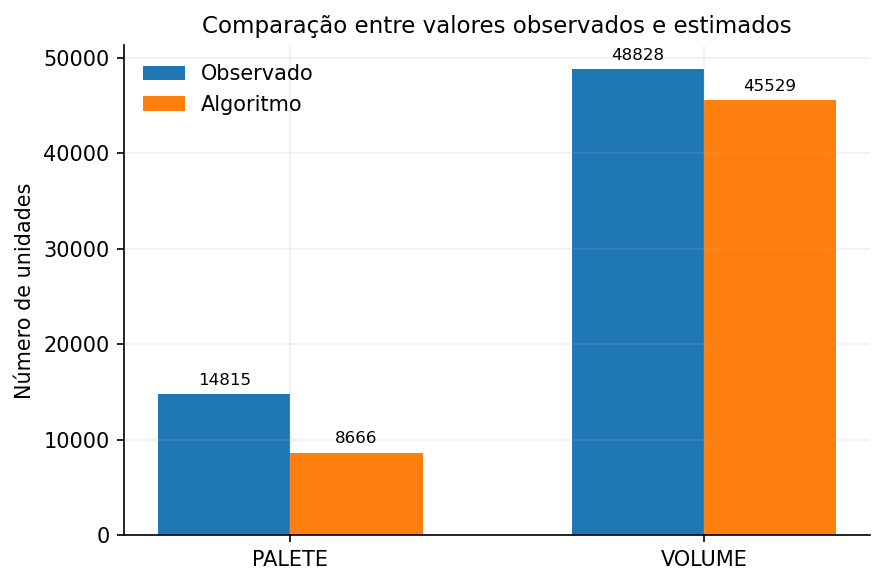

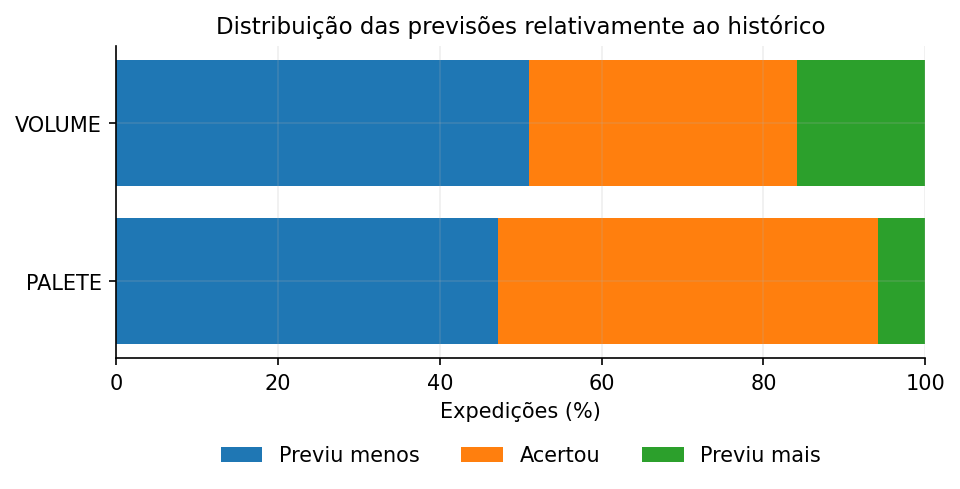

In [27]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
    "figure.dpi": 150
})

# Valores observados vs. estimados
fig, ax = plt.subplots(figsize=(6, 4))
cenarios = tabela_validacao["Cenário"]
x = np.arange(len(cenarios))
largura = 0.32

b1 = ax.bar(x - largura/2, tabela_validacao["Real"], largura, label="Observado")
b2 = ax.bar(x + largura/2, tabela_validacao["Algoritmo"], largura, label="Algoritmo")

ax.set_xticks(x)
ax.set_xticklabels(cenarios)
ax.set_ylabel("Número de unidades")
ax.set_title("Comparação entre valores observados e estimados")
ax.legend(frameon=False)
ax.bar_label(b1, padding=3, fontsize=8, fmt="%d")
ax.bar_label(b2, padding=3, fontsize=8, fmt="%d")

plt.tight_layout()
plt.savefig("validacao_real_vs_algoritmo.png", dpi=300, bbox_inches="tight")
plt.show()


# Distribuição das previsões
fig, ax = plt.subplots(figsize=(6.5, 3.5))
categorias = ["Previu menos", "Acertou", "Previu mais"]
colunas = ["Previu menos (%)", "Acertou (%)", "Previu mais (%)"]
y = np.arange(len(tabela_validacao))
esquerda = np.zeros(len(tabela_validacao))

for categoria, coluna in zip(categorias, colunas):
    valores = tabela_validacao[coluna].values
    ax.barh(y, valores, left=esquerda, label=categoria)
    esquerda += valores

ax.set_yticks(y)
ax.set_yticklabels(tabela_validacao["Cenário"])
ax.set_xlabel("Expedições (%)")
ax.set_xlim(0, 100)
ax.set_title("Distribuição das previsões relativamente ao histórico")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False)

plt.tight_layout()
#plt.savefig("validacao_distribuicao_resultados.png", dpi=300, bbox_inches="tight")
plt.show()

### VISUALIZAÇÃO 3D

StatementMeta(, 97f83c68-3395-43d8-a07c-6e2d62bc2811, 34, Finished, Available, Finished, False)


Shipment RI2613216 | 61 artigos | 4 paletes


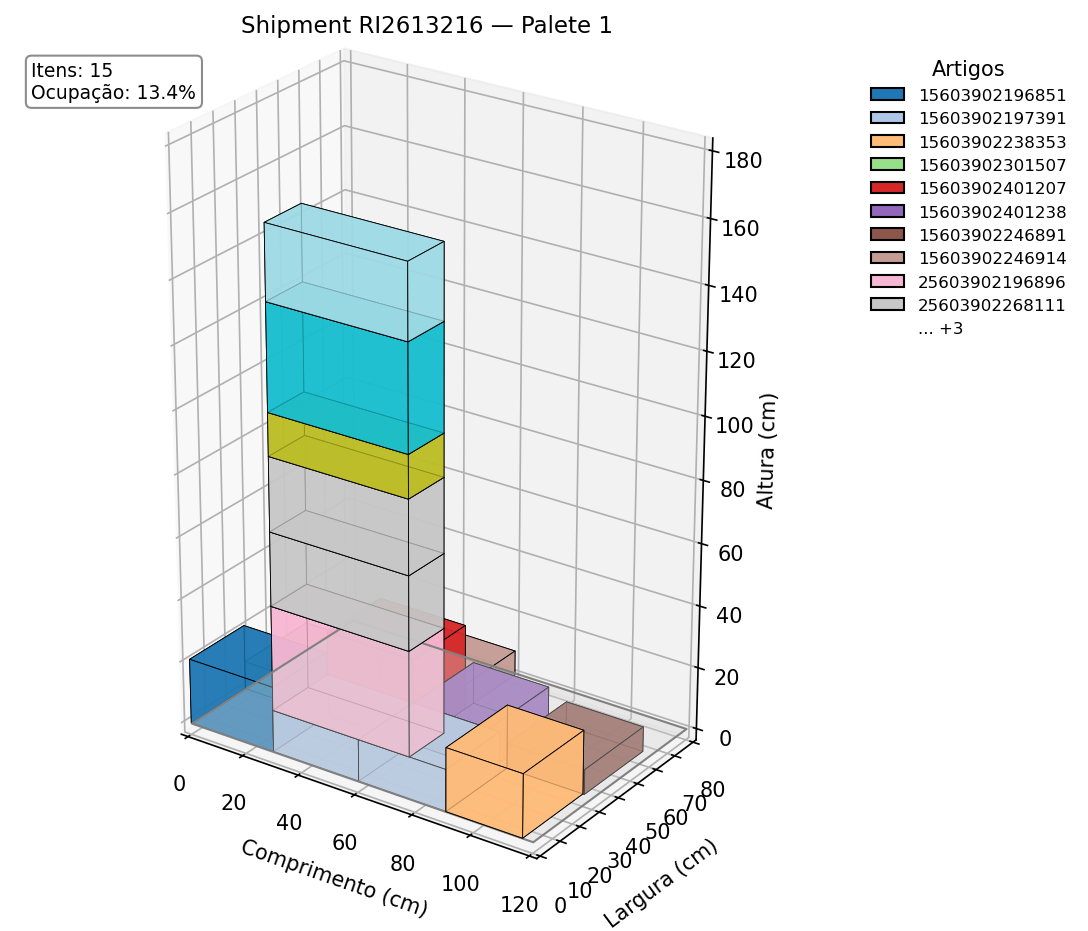

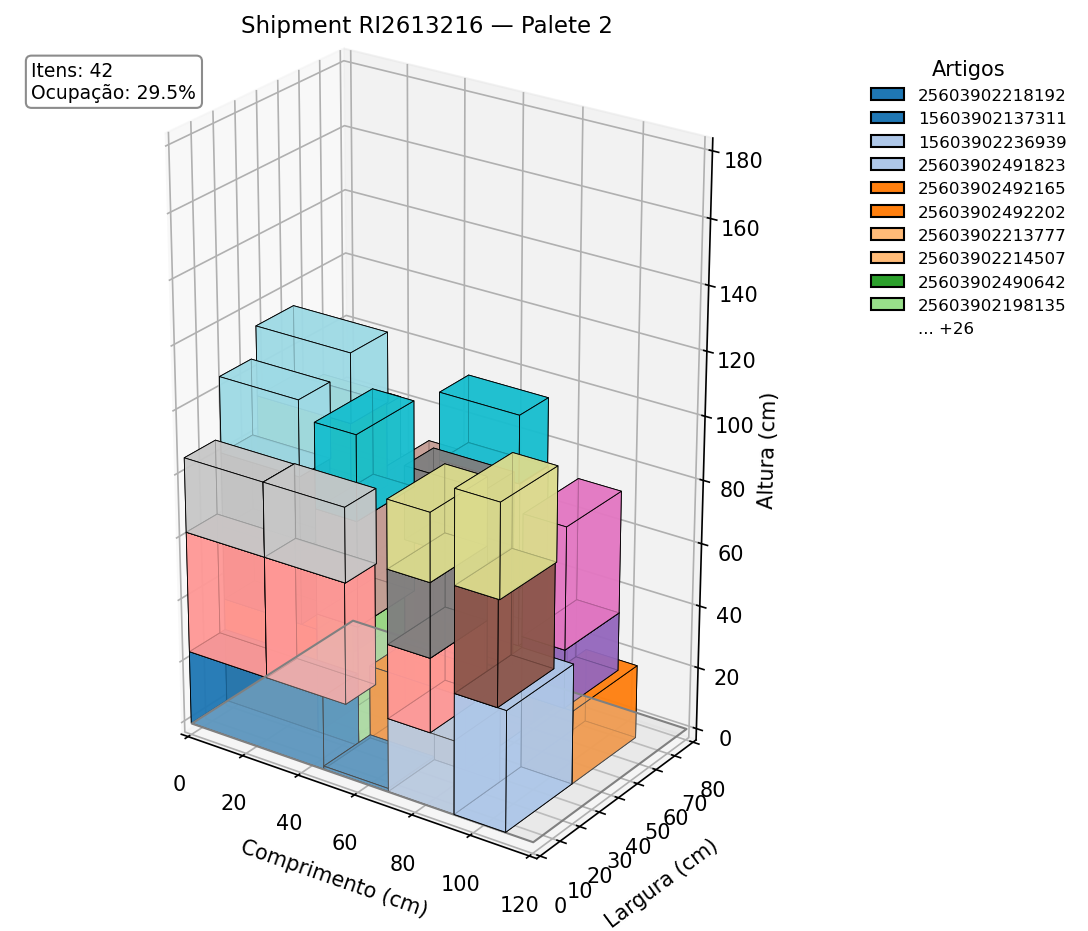

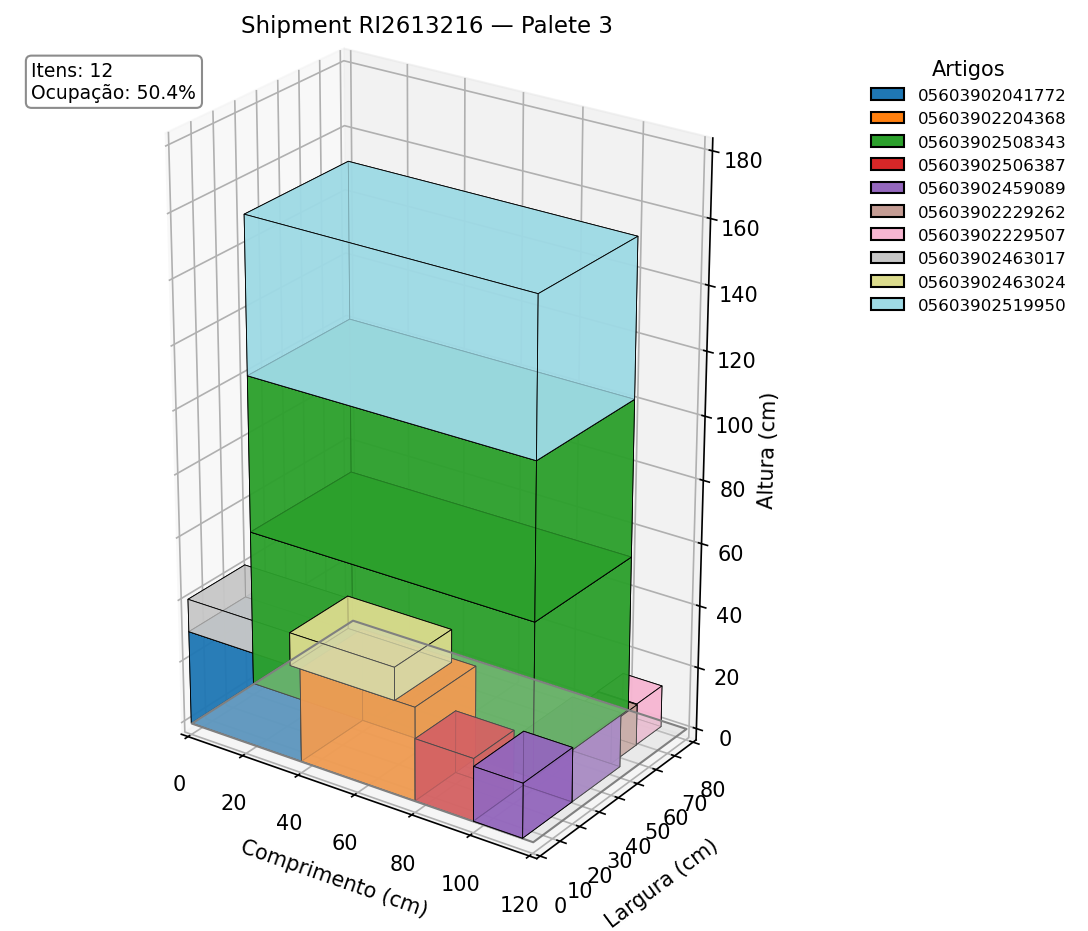

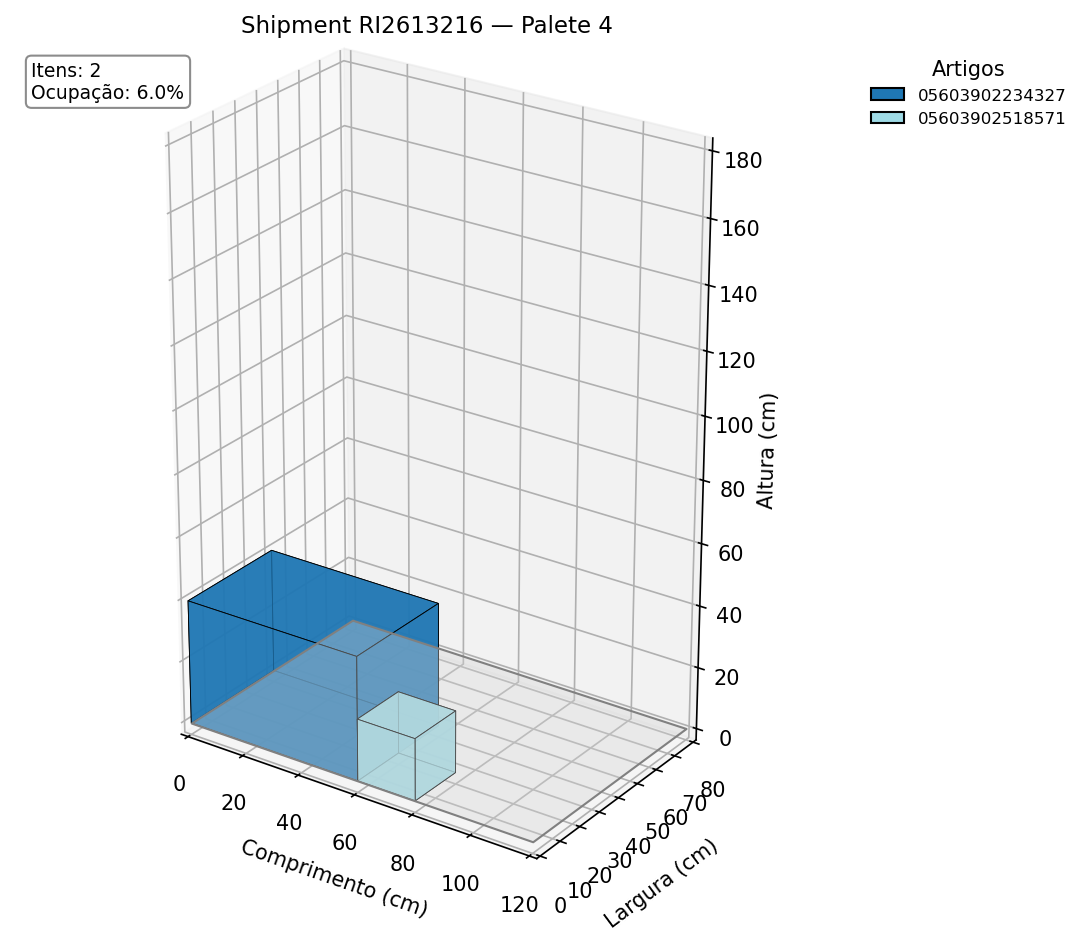


Shipment RI2612727 | 41 artigos | 9 paletes


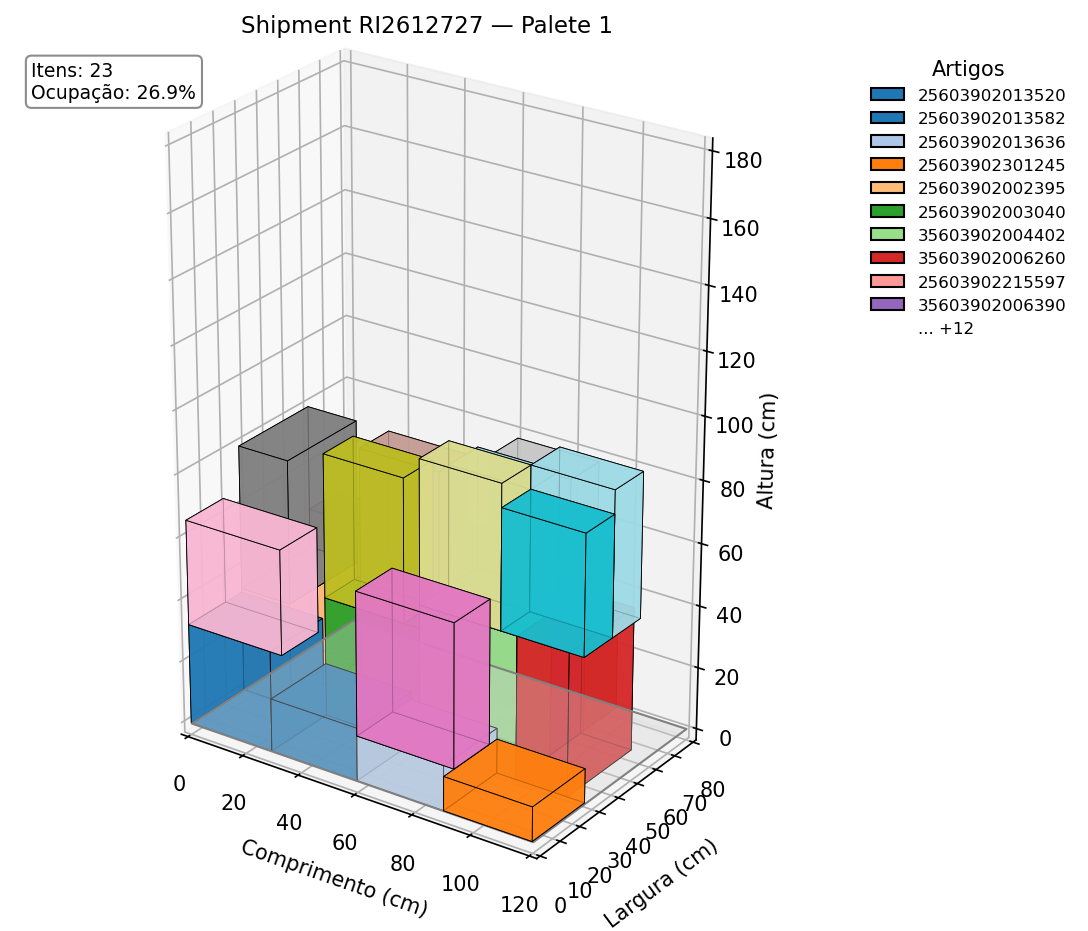

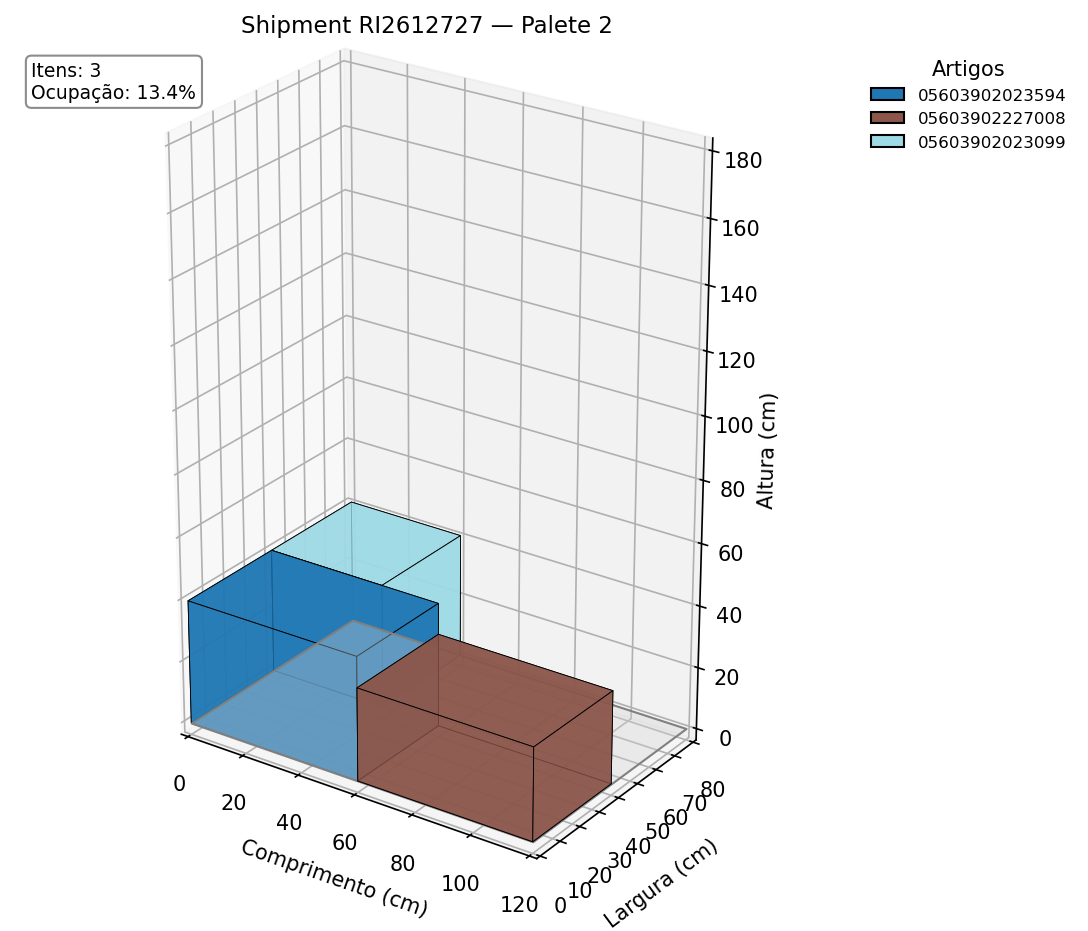

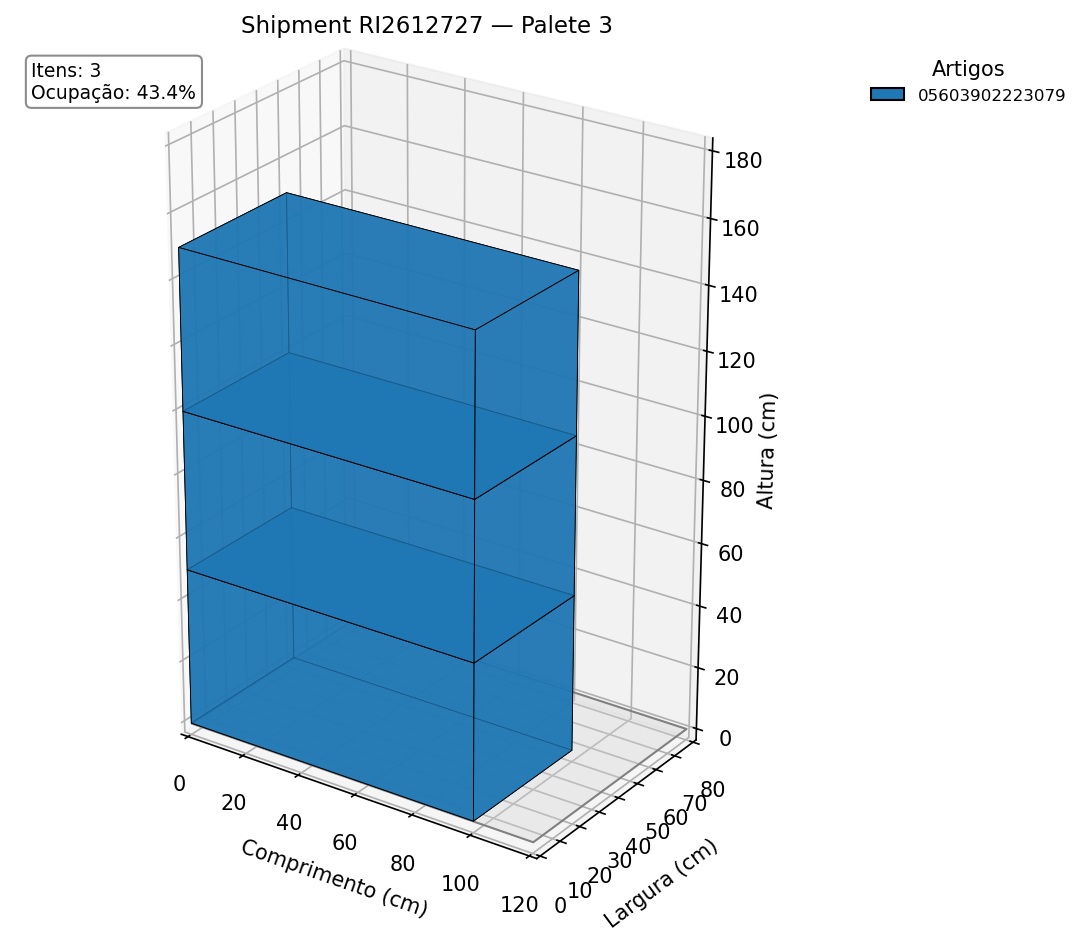

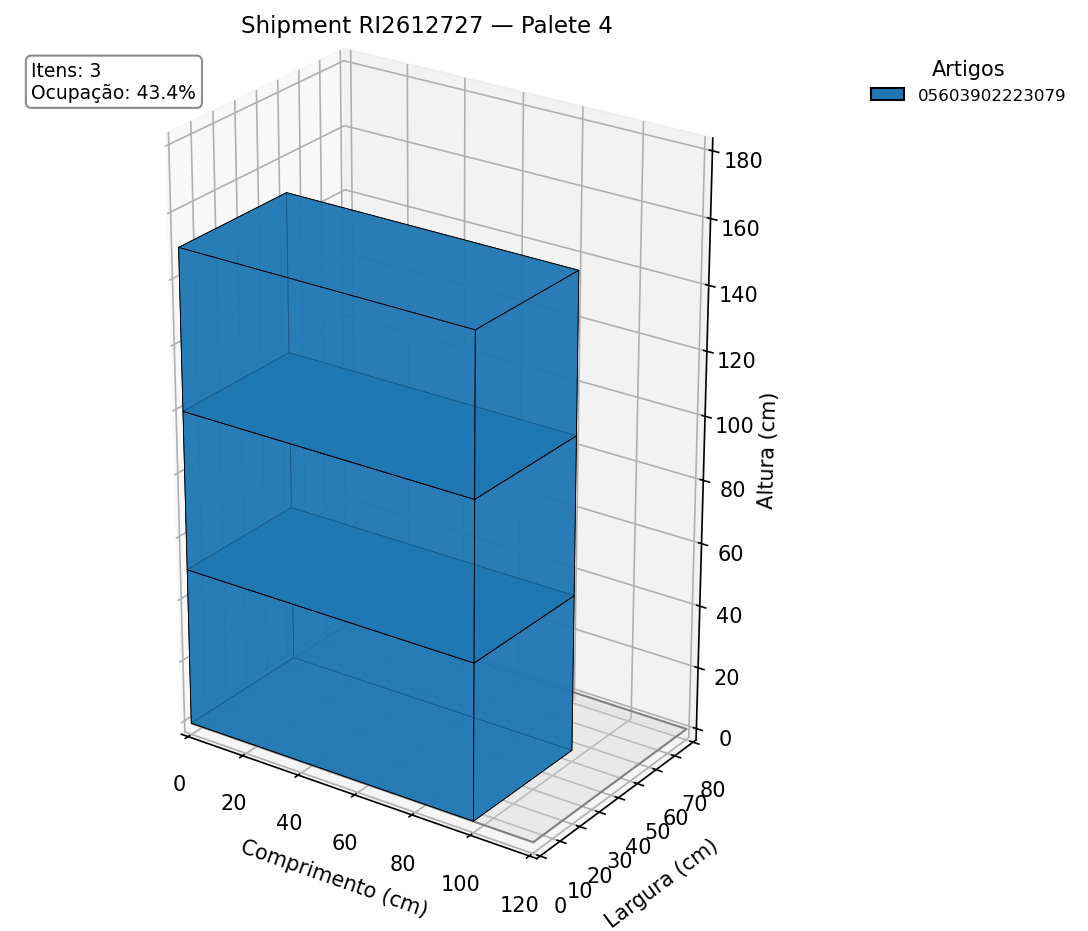

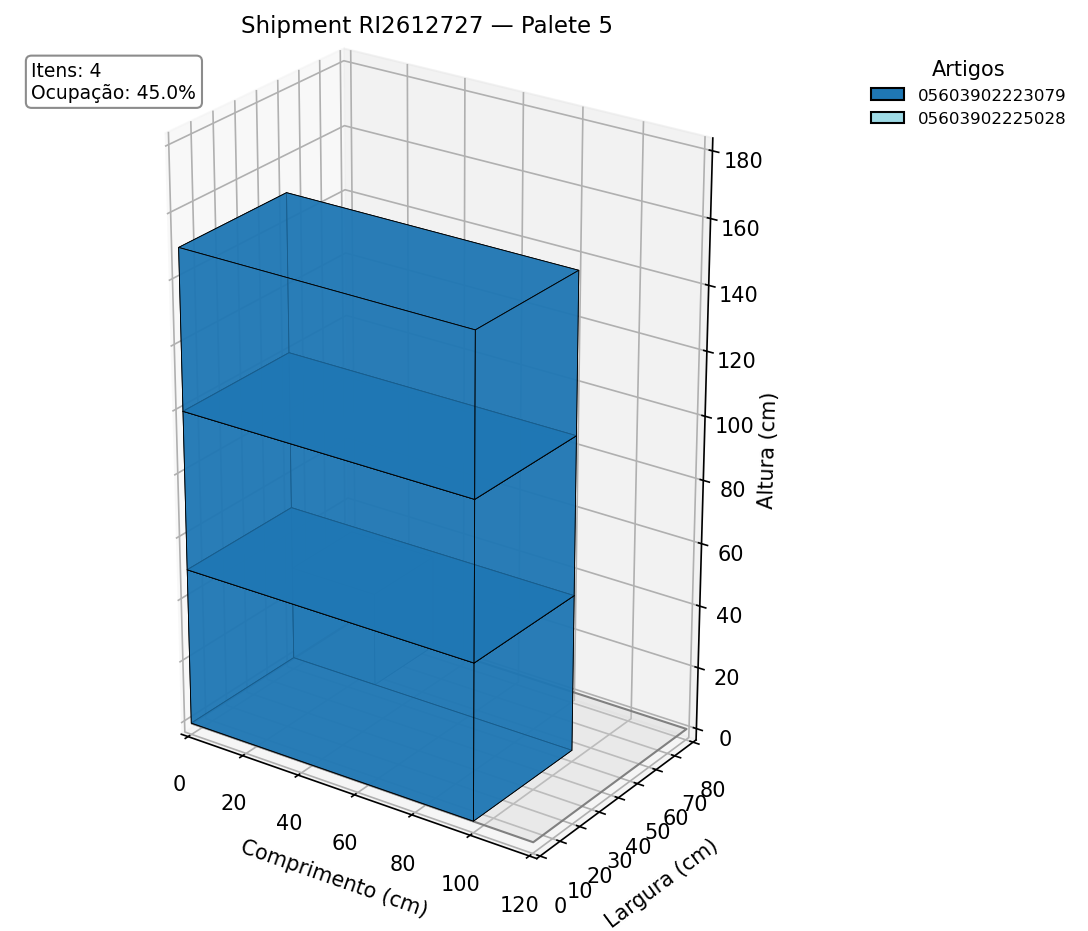

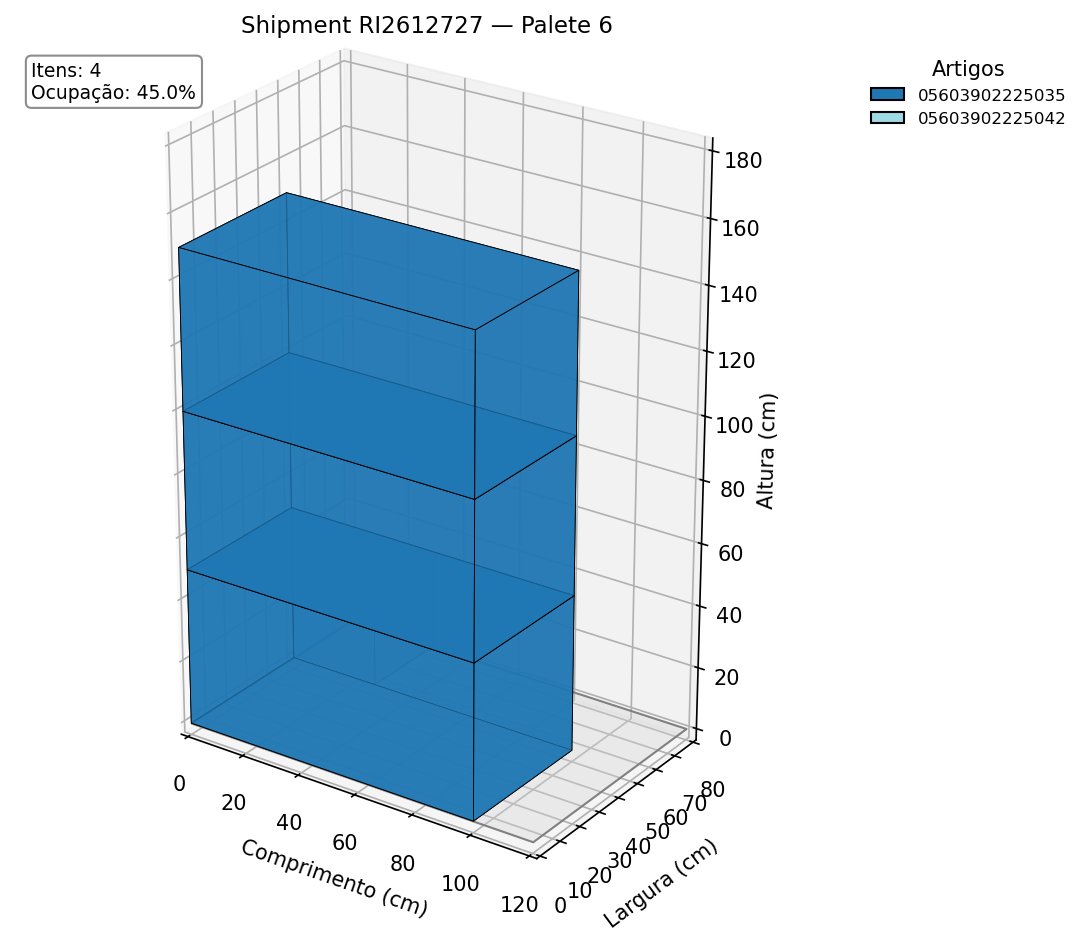

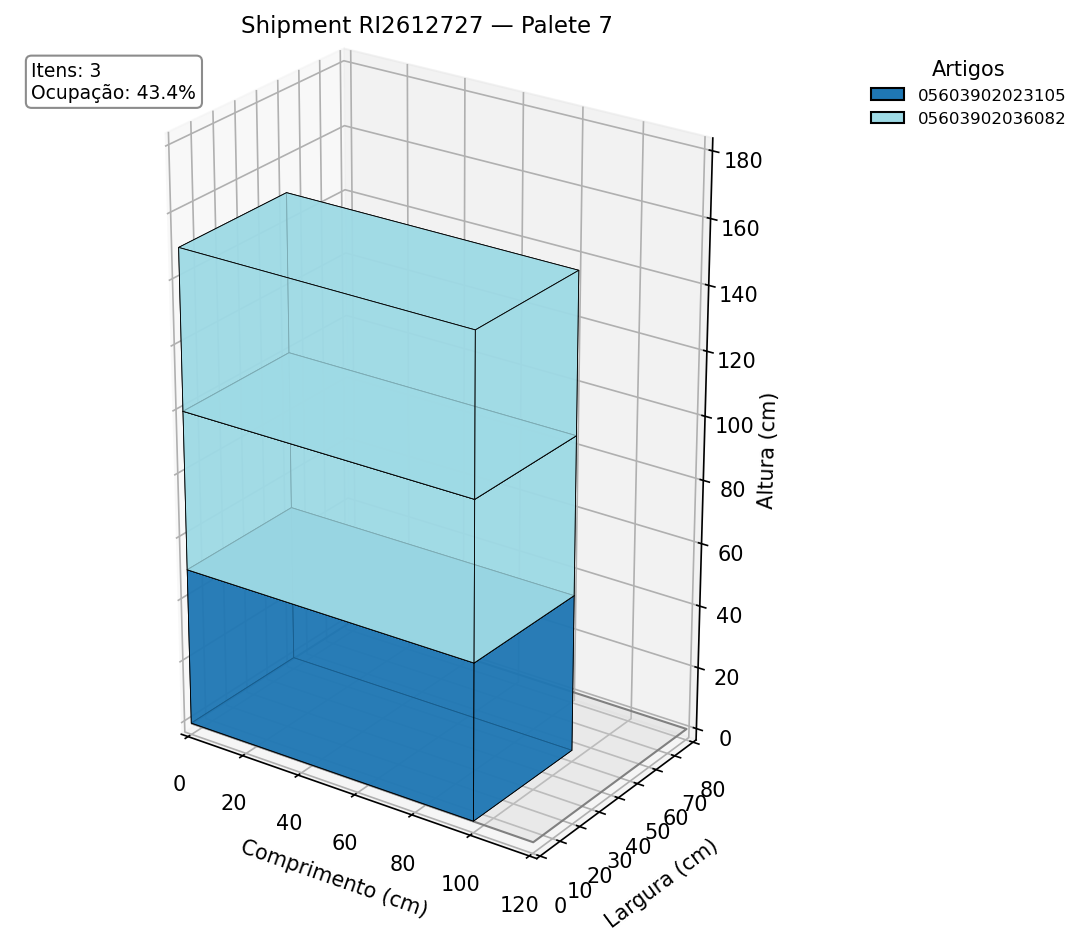

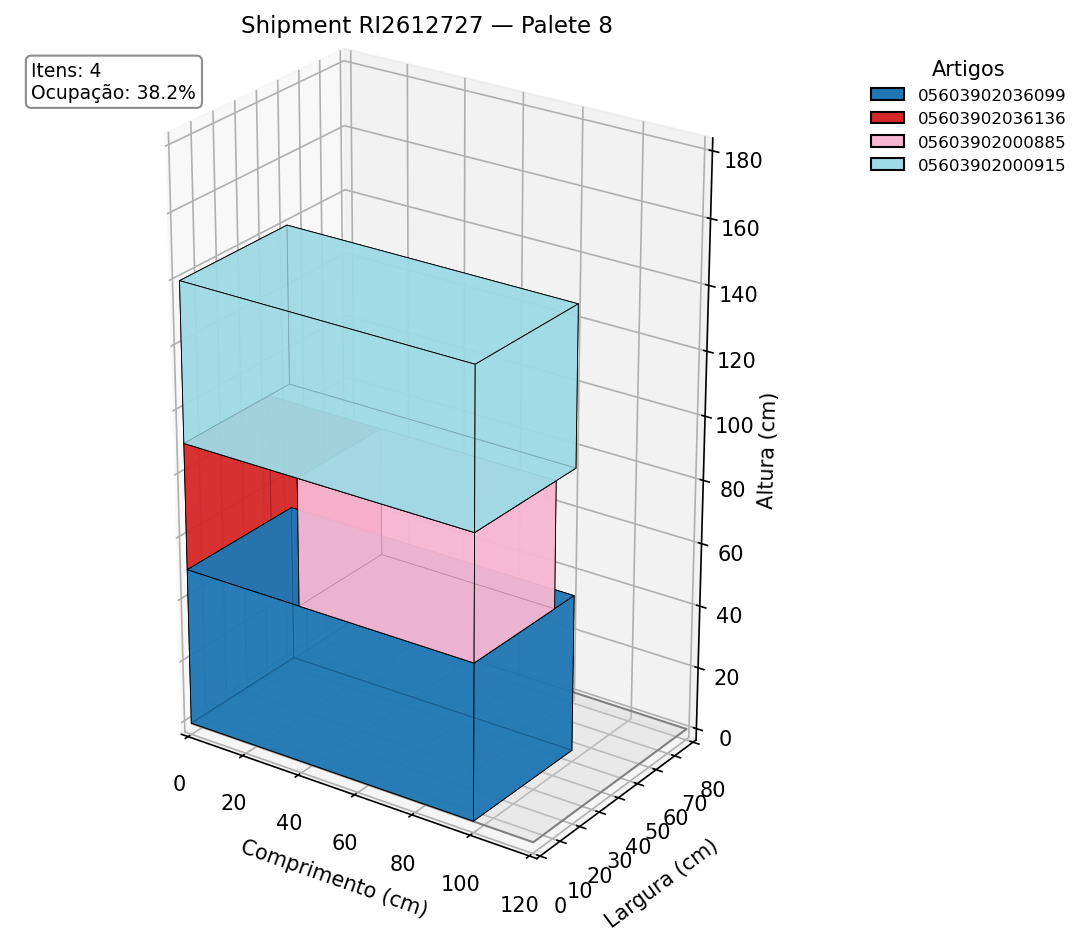

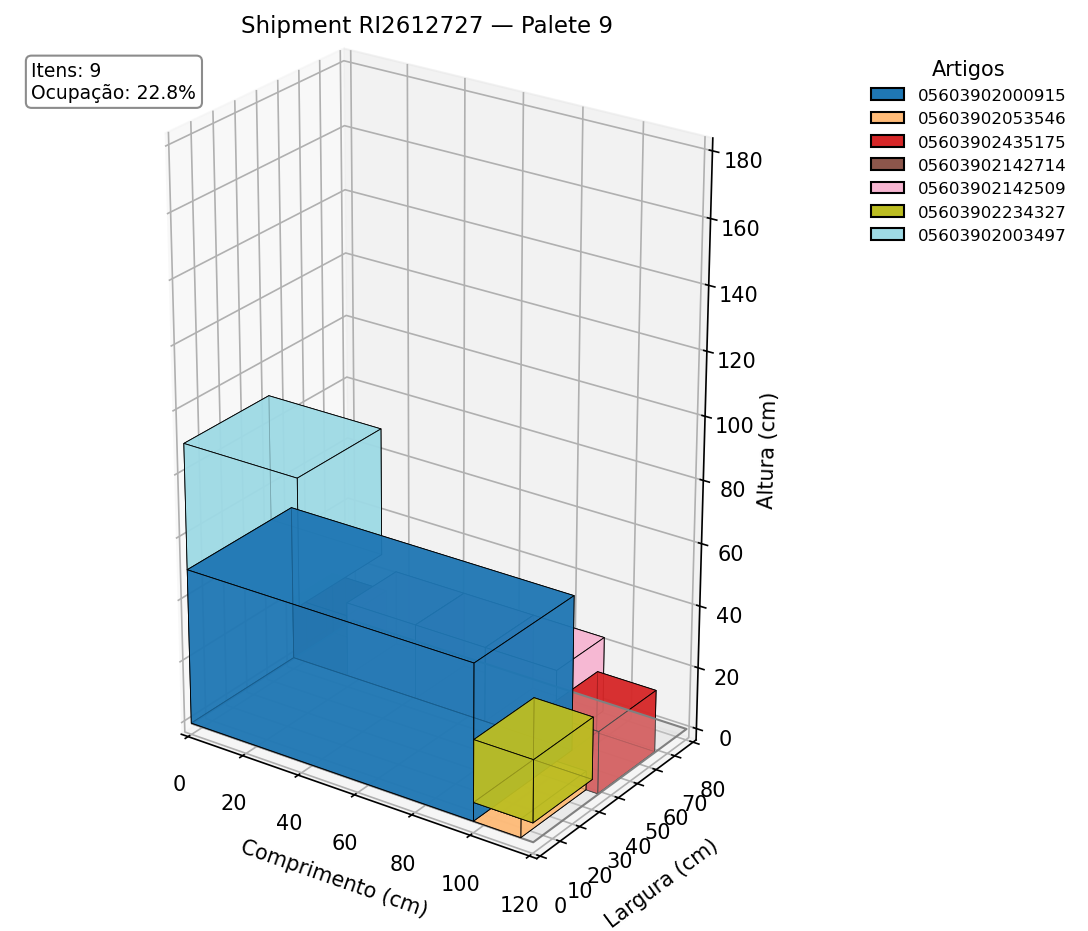


Shipment RI2613252 | 40 artigos | 7 paletes


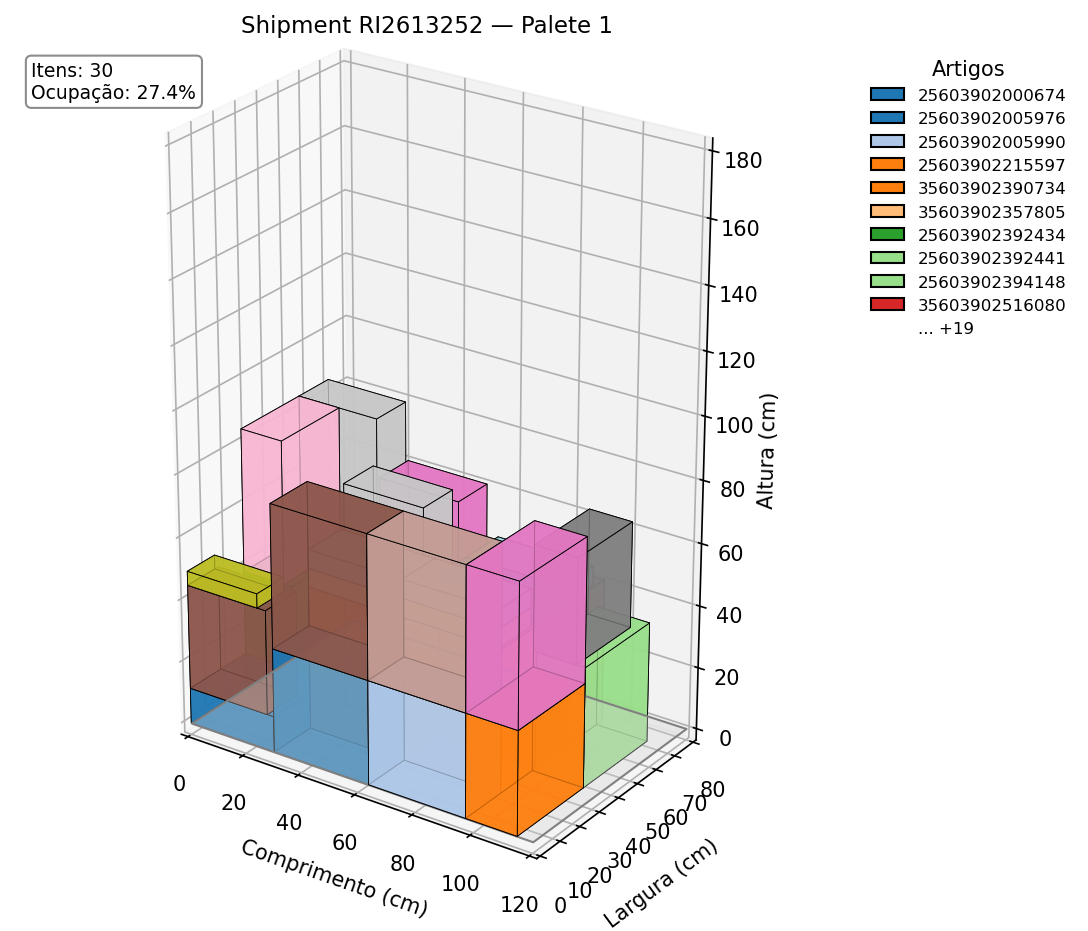

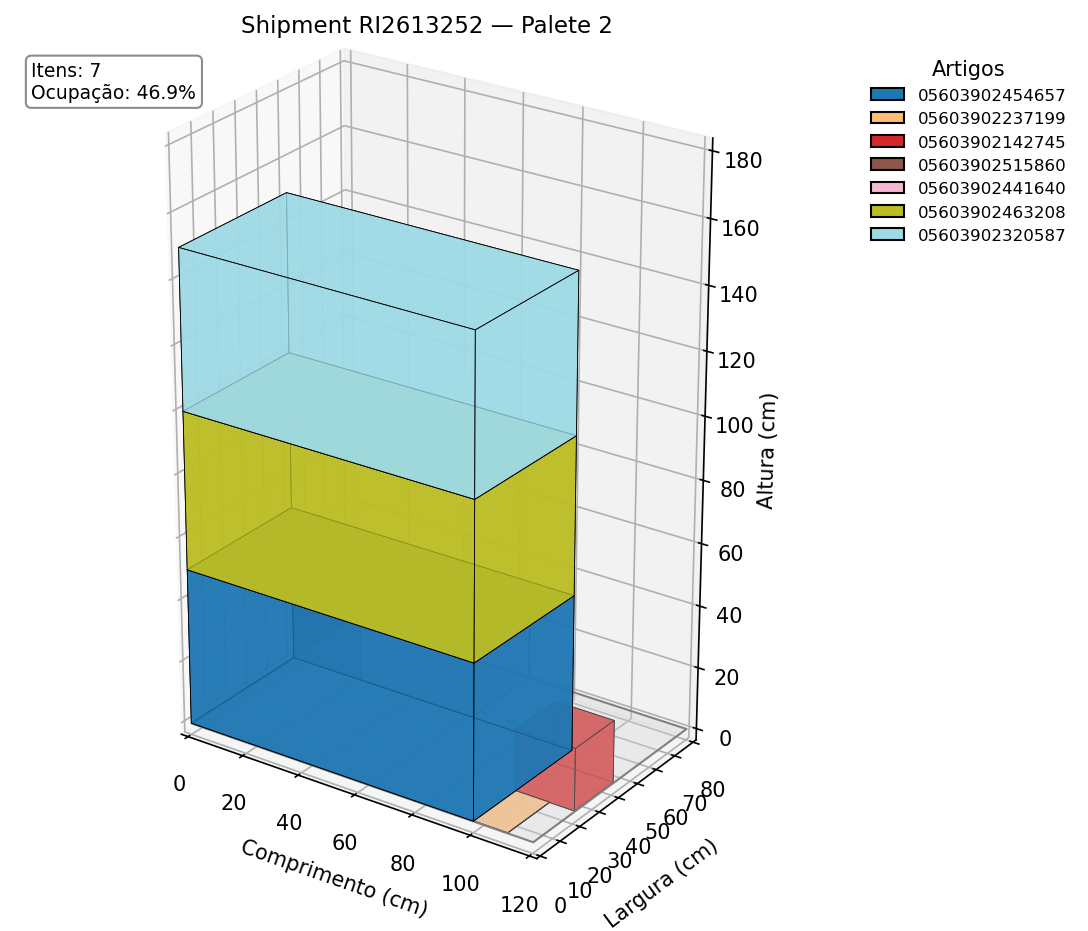

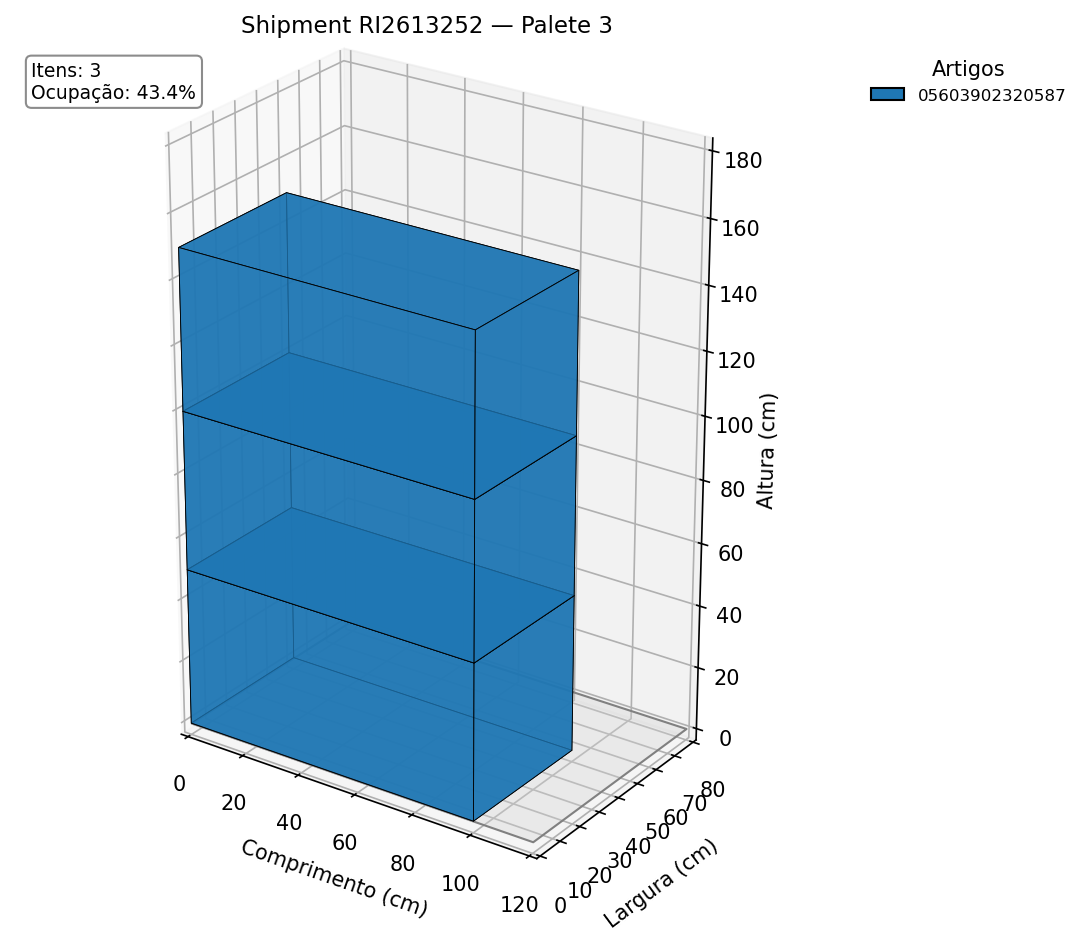

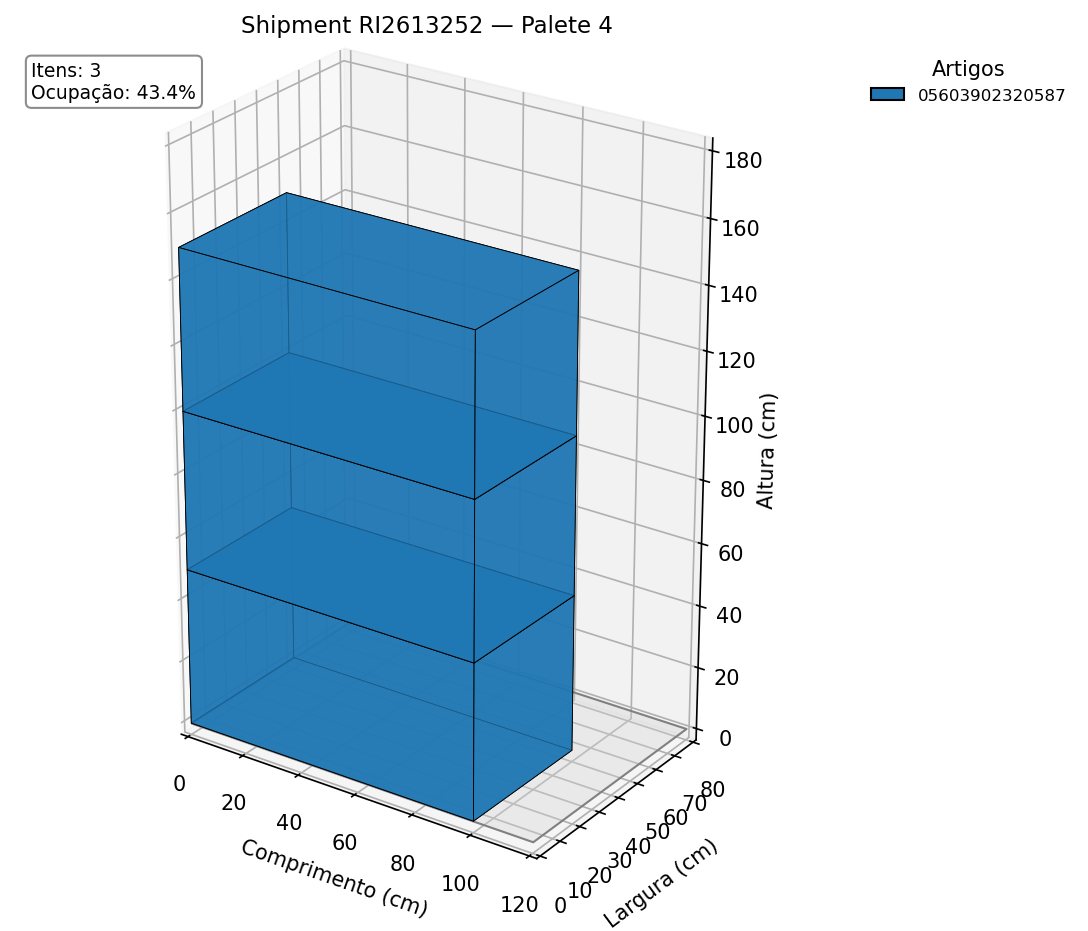

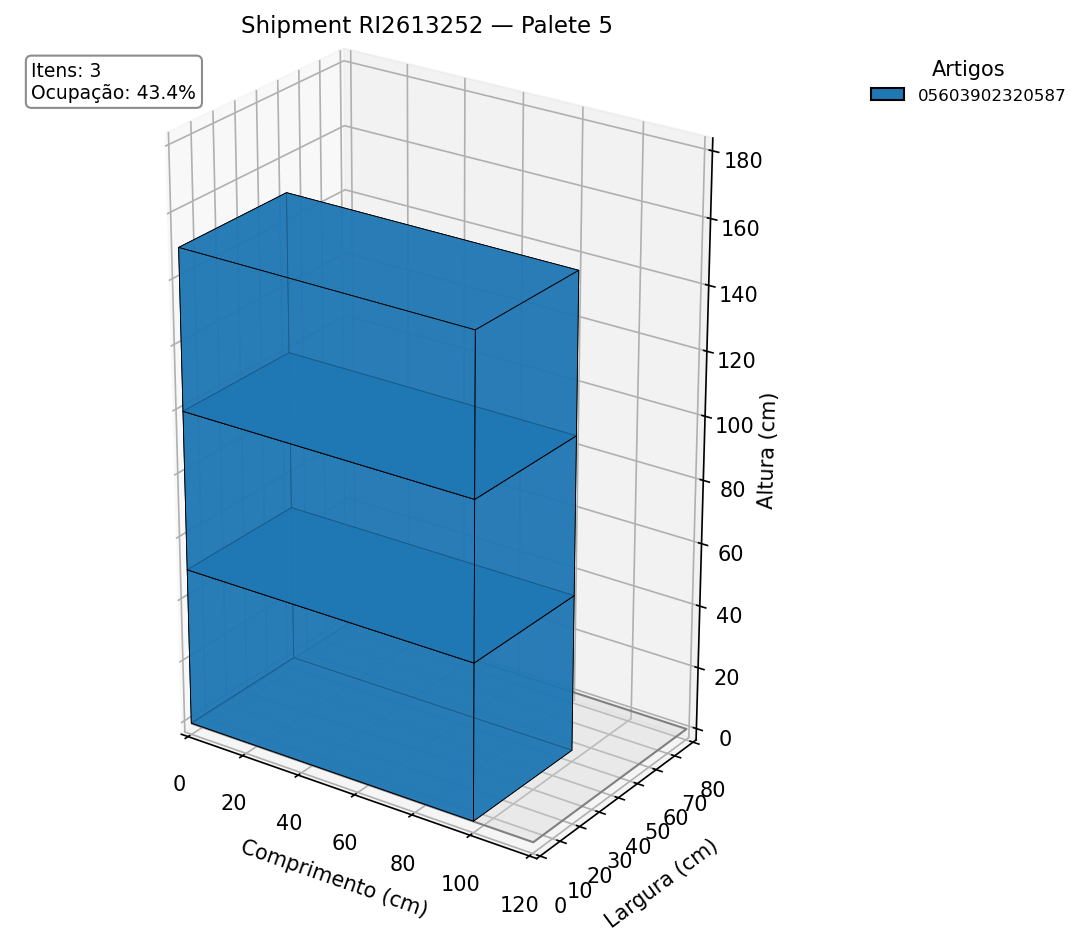

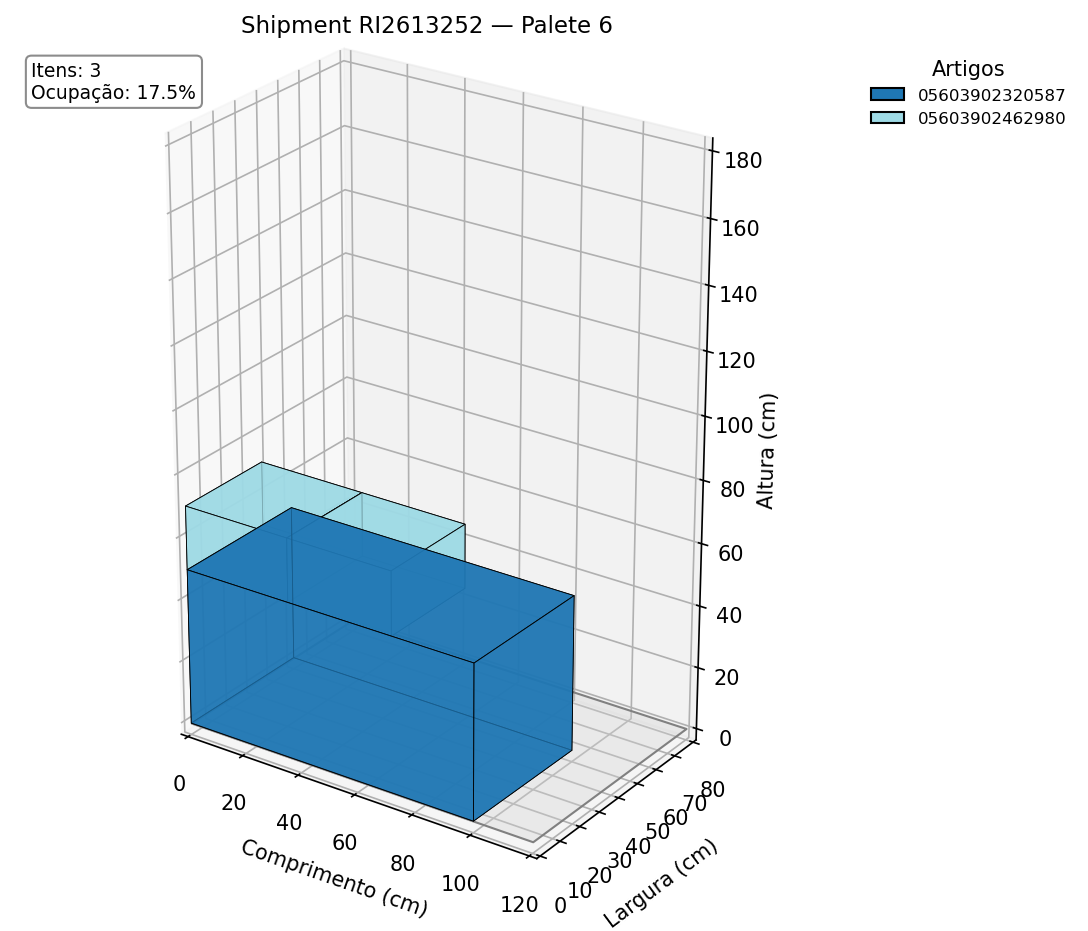

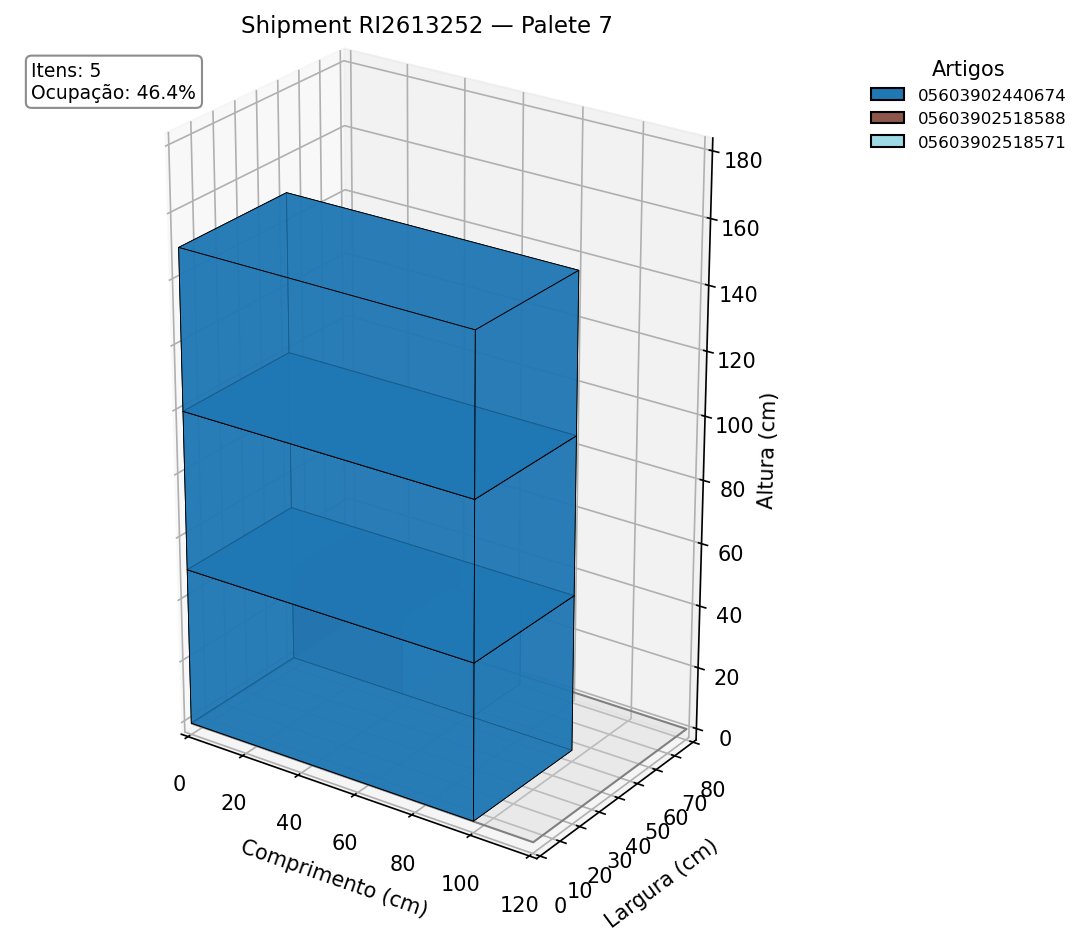


Shipment RI2612749 | 37 artigos | 2 paletes


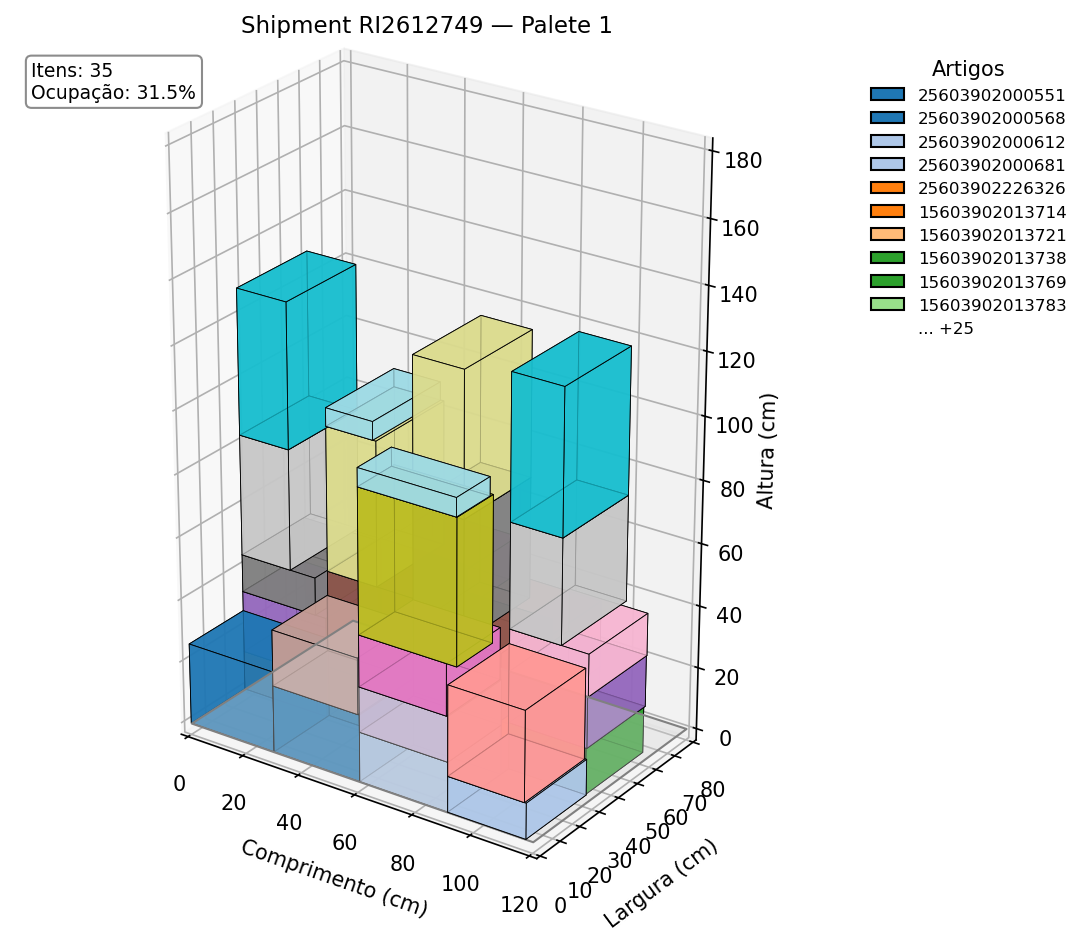

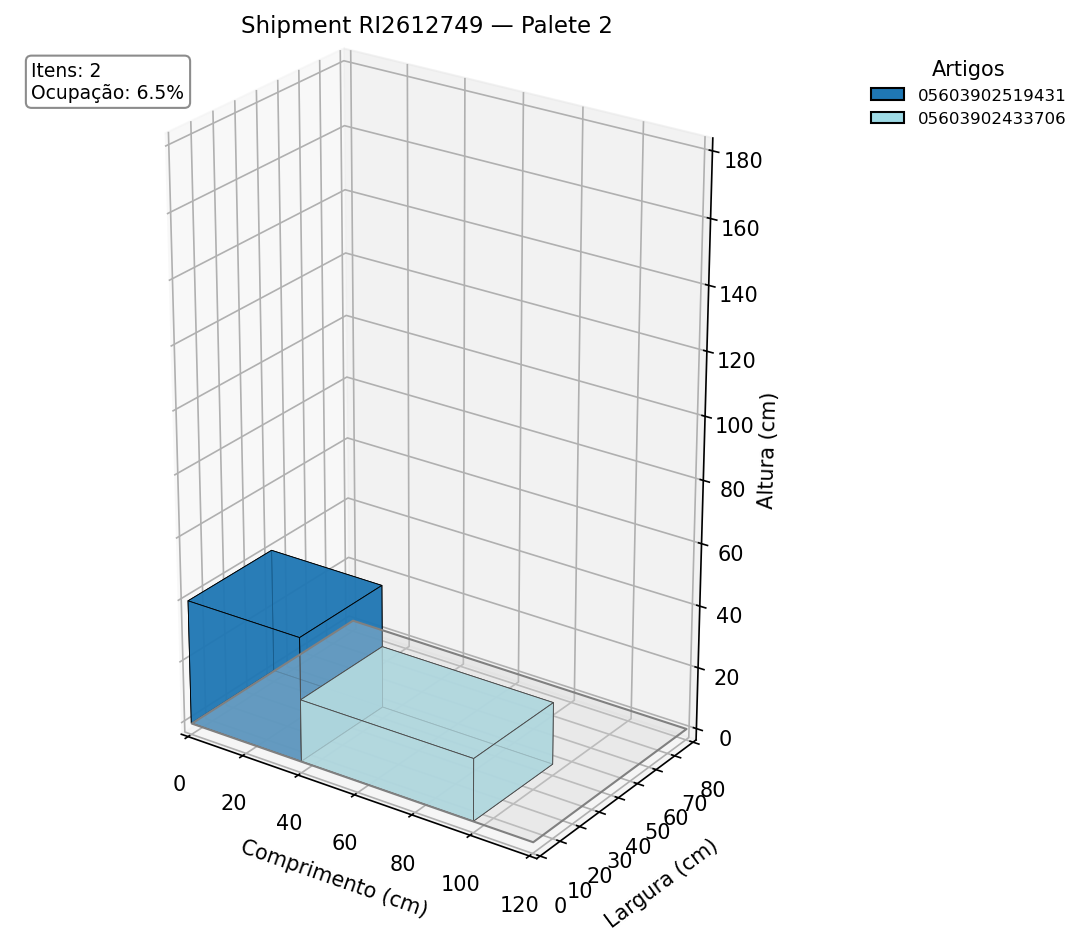


Shipment RI2613129 | 33 artigos | 2 paletes


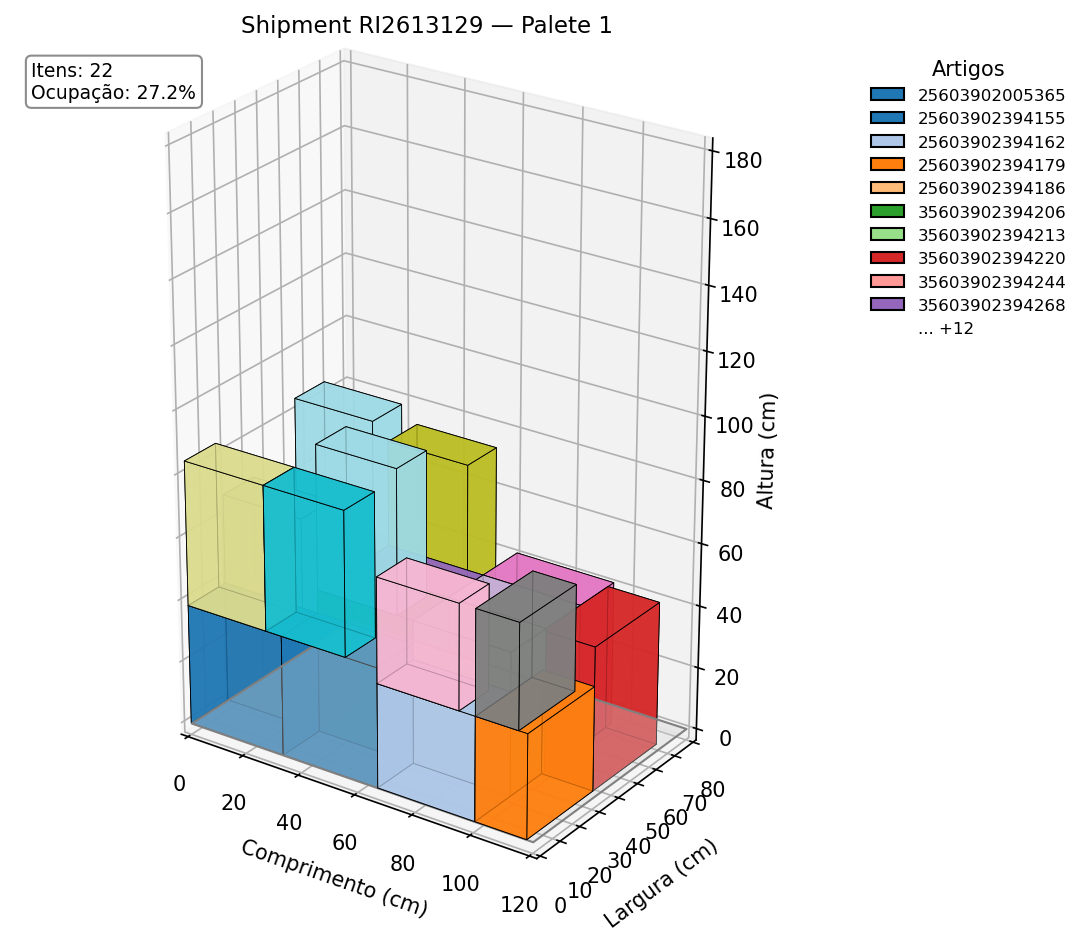

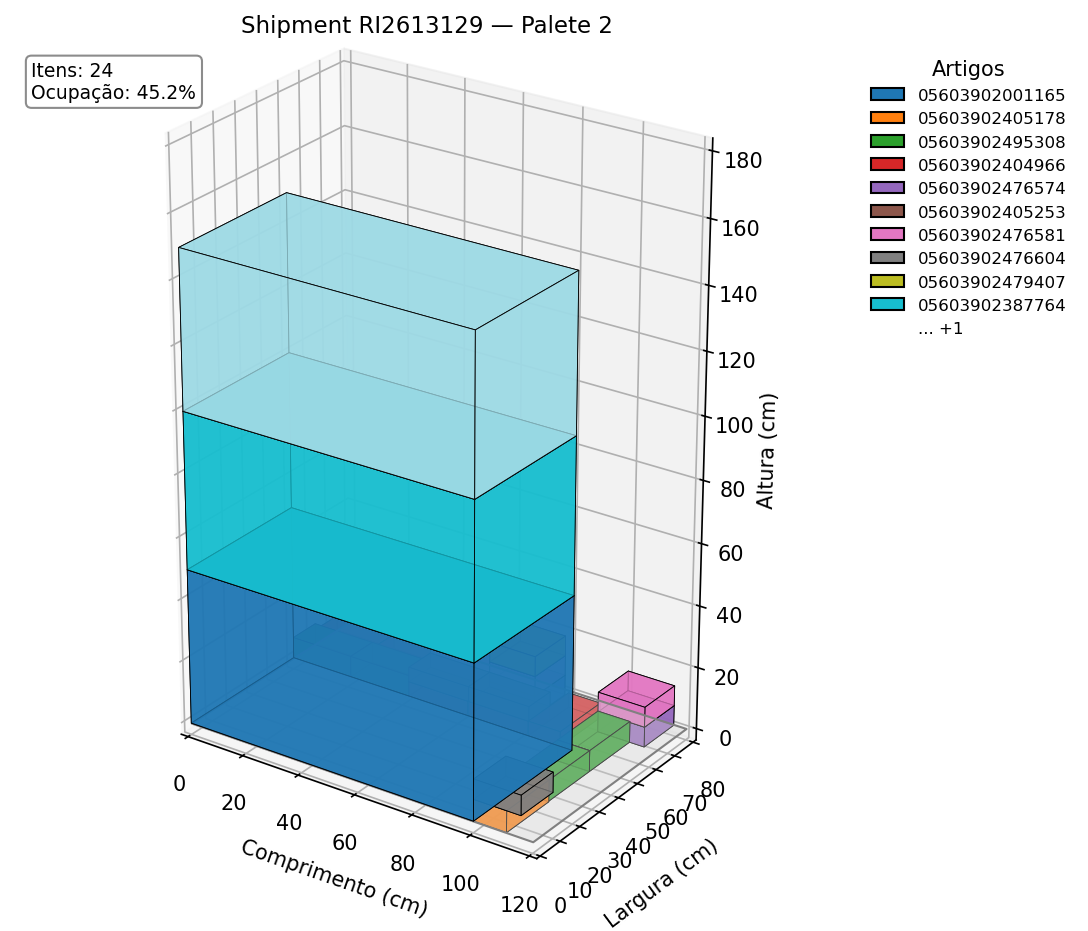

In [28]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np


def _faces_cuboide(x, y, z, l, w, h):
    v = [
        (x, y, z), (x+l, y, z), (x+l, y+w, z), (x, y+w, z),
        (x, y, z+h), (x+l, y, z+h), (x+l, y+w, z+h), (x, y+w, z+h)
    ]
    return [
        [v[0], v[1], v[2], v[3]],
        [v[4], v[5], v[6], v[7]],
        [v[0], v[1], v[5], v[4]],
        [v[1], v[2], v[6], v[5]],
        [v[2], v[3], v[7], v[6]],
        [v[3], v[0], v[4], v[7]]
    ]


def visualizar_palete_3d(output_df, shipment_no, pallet_id,
                         pl=PALLET_LENGTH_CM,
                         pw=PALLET_WIDTH_CM,
                         ph=PALLET_MAX_HEIGHT_CM):

    itens = output_df[
        (output_df["shipment_no"] == shipment_no) &
        (output_df["pallet_id"] == pallet_id)
    ]

    if itens.empty:
        return

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    artigos = itens["item_no"].unique()
    cmap = plt.colormaps["tab20"].resampled(max(len(artigos), 1))
    cores = {a: cmap(i) for i, a in enumerate(artigos)}

    # Base da palete
    base = [[(0,0,0),(pl,0,0),(pl,pw,0),(0,pw,0)]]
    ax.add_collection3d(
        Poly3DCollection(
            base,
            facecolor="lightgrey",
            edgecolor="grey",
            alpha=0.35
        )
    )

    # Caixas
    for _, r in itens.iterrows():

        caixa = Poly3DCollection(
            _faces_cuboide(
                r["position_x_cm"],
                r["position_y_cm"],
                r["position_z_cm"],
                r["box_length_cm"],
                r["box_width_cm"],
                r["box_height_cm"]
            ),
            facecolor=cores[r["item_no"]],
            edgecolor="black",
            linewidths=0.4,
            alpha=0.78
        )

        caixa.set_zsort("average")
        ax.add_collection3d(caixa)

    ax.set_xlim(0, pl)
    ax.set_ylim(0, pw)
    ax.set_zlim(0, ph)

    ax.set_xlabel("Comprimento (cm)")
    ax.set_ylabel("Largura (cm)")
    ax.set_zlabel("Altura (cm)")

    ax.set_box_aspect((pl, pw, ph))
    ax.view_init(elev=25, azim=-55)

    ax.set_title(f"Shipment {shipment_no} — Palete {int(pallet_id)}")

    # Legenda resumida
    handles = [
        Patch(facecolor=cores[a], edgecolor="black", label=str(a))
        for a in artigos[:10]
    ]

    if len(artigos) > 10:
        handles.append(Patch(facecolor="white", edgecolor="white",
                             label=f"... +{len(artigos)-10}"))

    ax.legend(
        handles=handles,
        title="Artigos",
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        fontsize=8,
        frameon=False
    )

    volume_caixas = (
        itens["box_length_cm"] *
        itens["box_width_cm"] *
        itens["box_height_cm"]
    ).sum()

    ocupacao = volume_caixas / (pl * pw * ph) * 100

    ax.text2D(
        0.02,
        0.98,
        f"Itens: {len(itens)}\nOcupação: {ocupacao:.1f}%",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round", fc="white", ec="grey", alpha=0.9)
    )

    plt.tight_layout()
    plt.savefig(
        f"palete_3d_{shipment_no}_{int(pallet_id)}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close()


# Top 5 shipments mais complexos
shipments_exemplo = (
    output_df.groupby("shipment_no")["item_no"]
    .nunique()
    .reset_index(name="n_items")
    .query("n_items > 20")
    .nlargest(5, "n_items")
)

for _, r in shipments_exemplo.iterrows():

    shipment = r["shipment_no"]

    paletes = sorted(
        output_df.loc[
            output_df["shipment_no"] == shipment,
            "pallet_id"
        ].unique()
    )

    print(
        f"\nShipment {shipment} | "
        f"{int(r['n_items'])} artigos | "
        f"{len(paletes)} paletes"
    )

    for p in paletes:
        visualizar_palete_3d(output_df, shipment, p)